In [1]:
# Import packages
from pathlib import Path

project_dir = Path("/home/mcaskey/10XvParse/")
species = "hsapiens"
index_dir = project_dir / "Index" / "human"
analysis_name = "Analysis_7"
analysis_dir = Path.cwd() 

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scrublet as scr
import pandas as pd
import anndata as ad
import scanpy as sc

from XvP_utils import plotting

In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [4]:
# # In case you change the package
# import importlib
# importlib.reload(plotting)

In [5]:
data_10x = plotting.init_processing(analysis_name=analysis_name, project_dir=project_dir, data_name='10x', assay ="10x", data_title='10X Genomics')
data_polyT = plotting.init_processing(analysis_name=analysis_name, project_dir=project_dir, data_name='polyT', assay="parse", data_title='Parse 3\'')
data_randO = plotting.init_processing(analysis_name=analysis_name, project_dir=project_dir, data_name='randO', assay="parse", data_title='Parse Random Oligo')
data_parse = plotting.init_processing(analysis_name=analysis_name, project_dir=project_dir, data_name='parse', assay="parse", data_title='Parse', modified=True)

raw_datasets = [data_10x, data_polyT, data_randO, data_parse]

# Population Upsampling Estimation

PreSeq output already exists for all datasets.


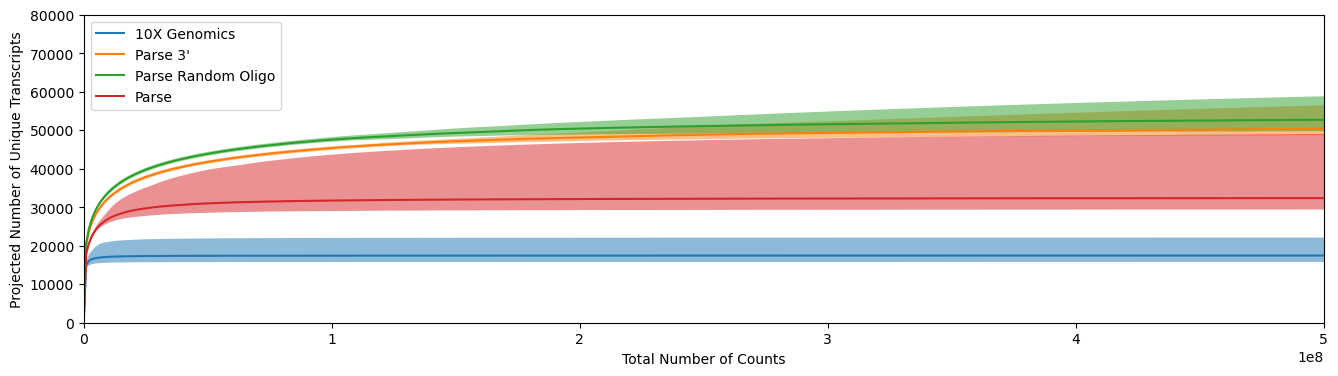

In [6]:
# Launches PreSeq in the background — does not block the notebook.
# Rerun plot_upsample() in a later cell once jobs complete.
plotting.upsample(raw_datasets, Path("preseq"), overwrite=False)
plotting.plot_upsample(raw_datasets, Path("preseq"), xlim=5e8, ylim=8e4)

# Quality Control Comparison

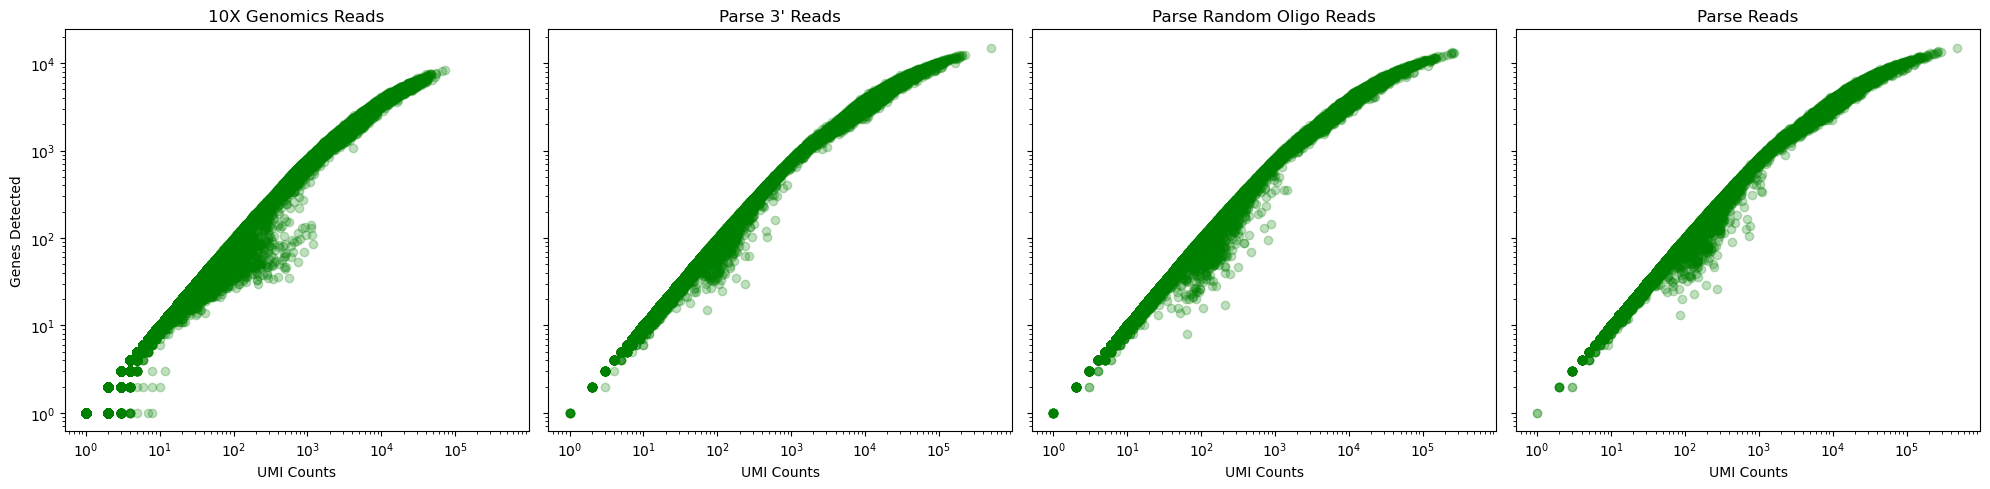

In [7]:
fig, ax = plt.subplots(1, 4, figsize=(20,5), sharey=True, sharex=True)

for i, data in enumerate(raw_datasets):
    plotting.scatter_reads(ax[i], data)

ax[0].set_ylabel("Genes Detected")

plt.tight_layout()
plt.show()

In [8]:
# Path to save gene metadata so don't need to query Ensembl more than once
index_dir = project_dir / "Index" / "human"
gene_info = plotting.query_ensembl(analysis_dir, index_dir=index_dir, overwrite=True) 

In [9]:
for data in raw_datasets:
    plotting.add_cell_metrics(data, gene_info)

/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


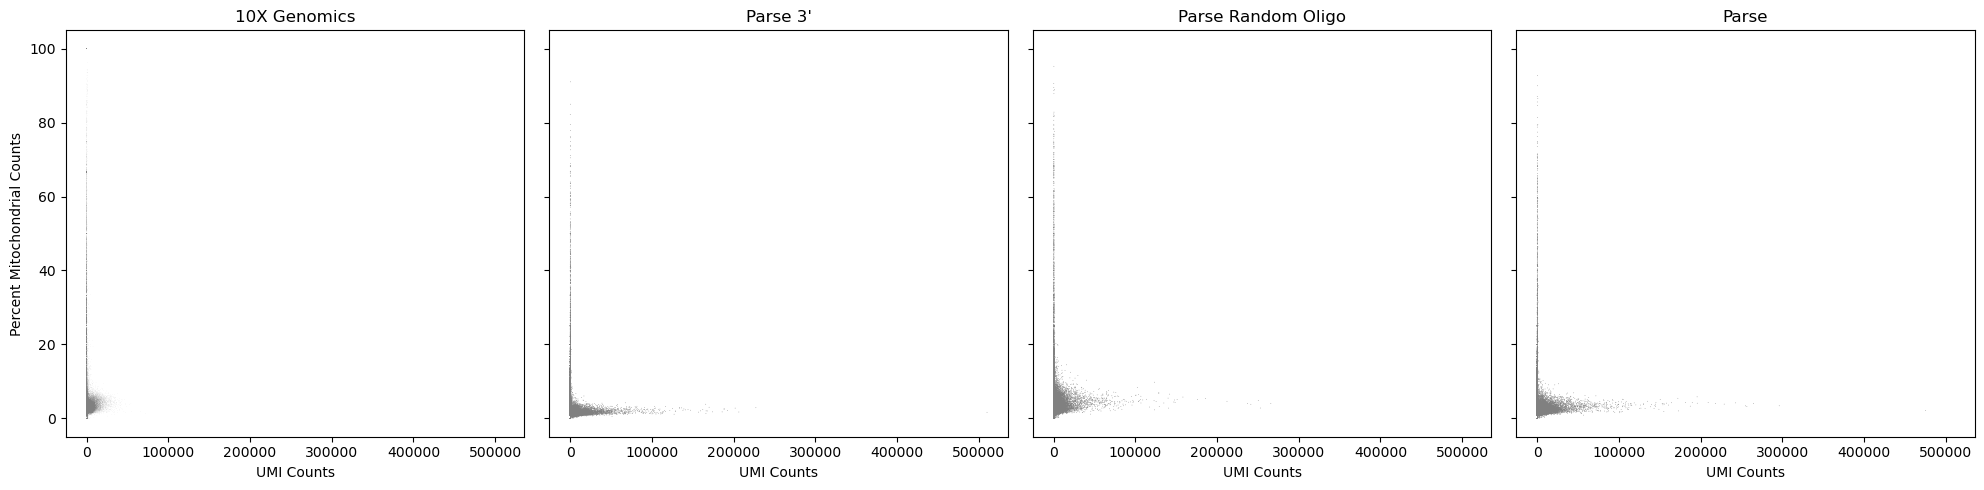

In [10]:
fig, ax = plt.subplots(1, 4, figsize=(20,5), sharey=True,sharex=True)
for i, data in enumerate(raw_datasets):
    plotting.mito_scatter(ax[i], data)

ax[0].set_ylabel("Percent Mitochondrial Counts")

plt.tight_layout()
plt.show()

39,101 cells passed the 200 UMI threshold for 10X Genomics


9,122 cells passed the 600 UMI threshold for Parse 3'


9,447 cells passed the 600 UMI threshold for Parse Random Oligo


9,829 cells passed the 600 UMI threshold for Parse


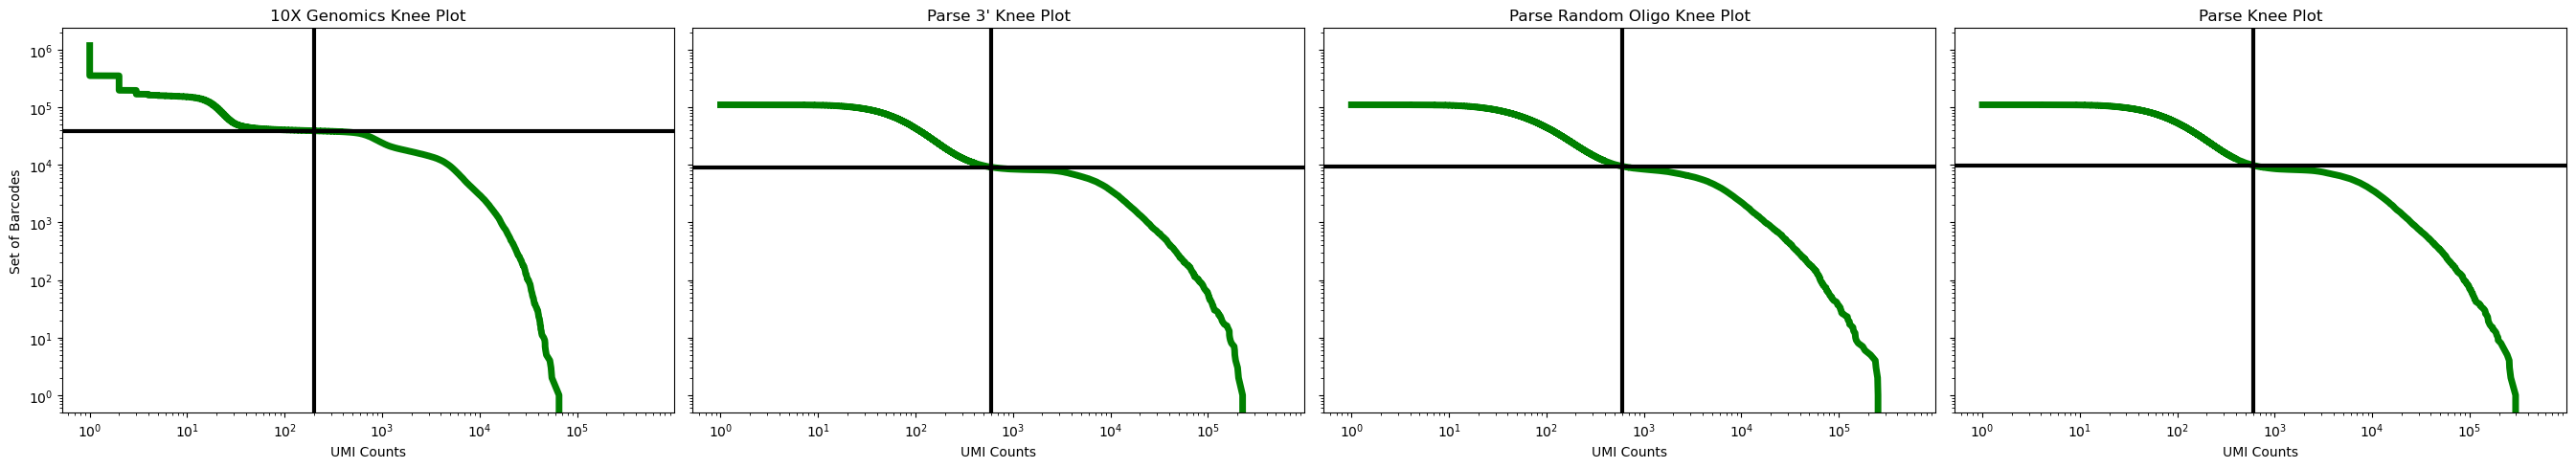

In [11]:
fig, ax = plt.subplots(1, 4, figsize=(27,5), sharey=True, sharex=True)

cutoffs = [200, 600, 600, 600]

datasets = []
for i, (data, cutoff) in enumerate(zip(raw_datasets, cutoffs)):
    datasets.append(plotting.knee_plot(ax[i], data, cutoff=cutoff))

ax[0].set_ylabel("Set of Barcodes")

plt.tight_layout()
plt.show()

In [12]:
full_gene_info_path = project_dir / analysis_dir 
gene_info = plotting.update_gene_info(gene_info, datasets, full_gene_info_path)

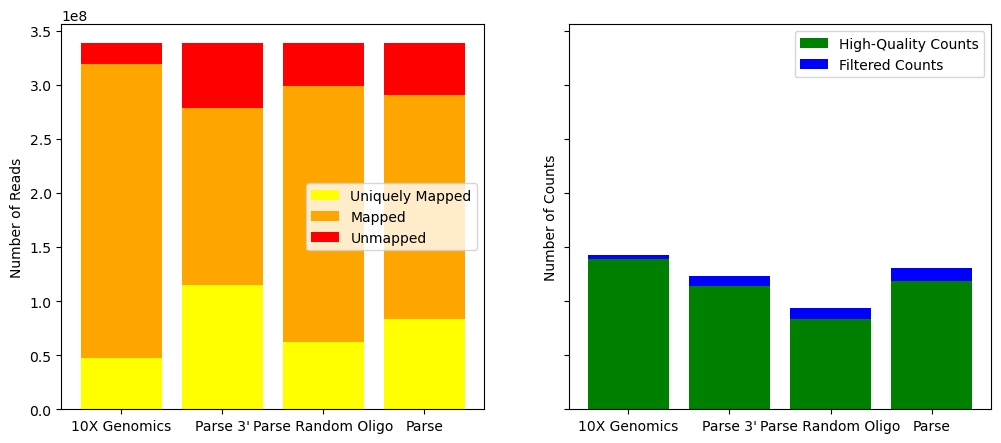

In [13]:
plotting.plot_filtering_metrics(datasets)

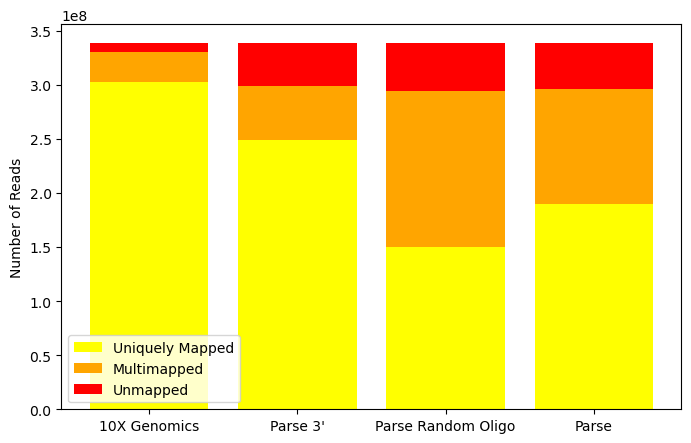

In [14]:
plotting.plot_filtering_metrics_star(datasets)

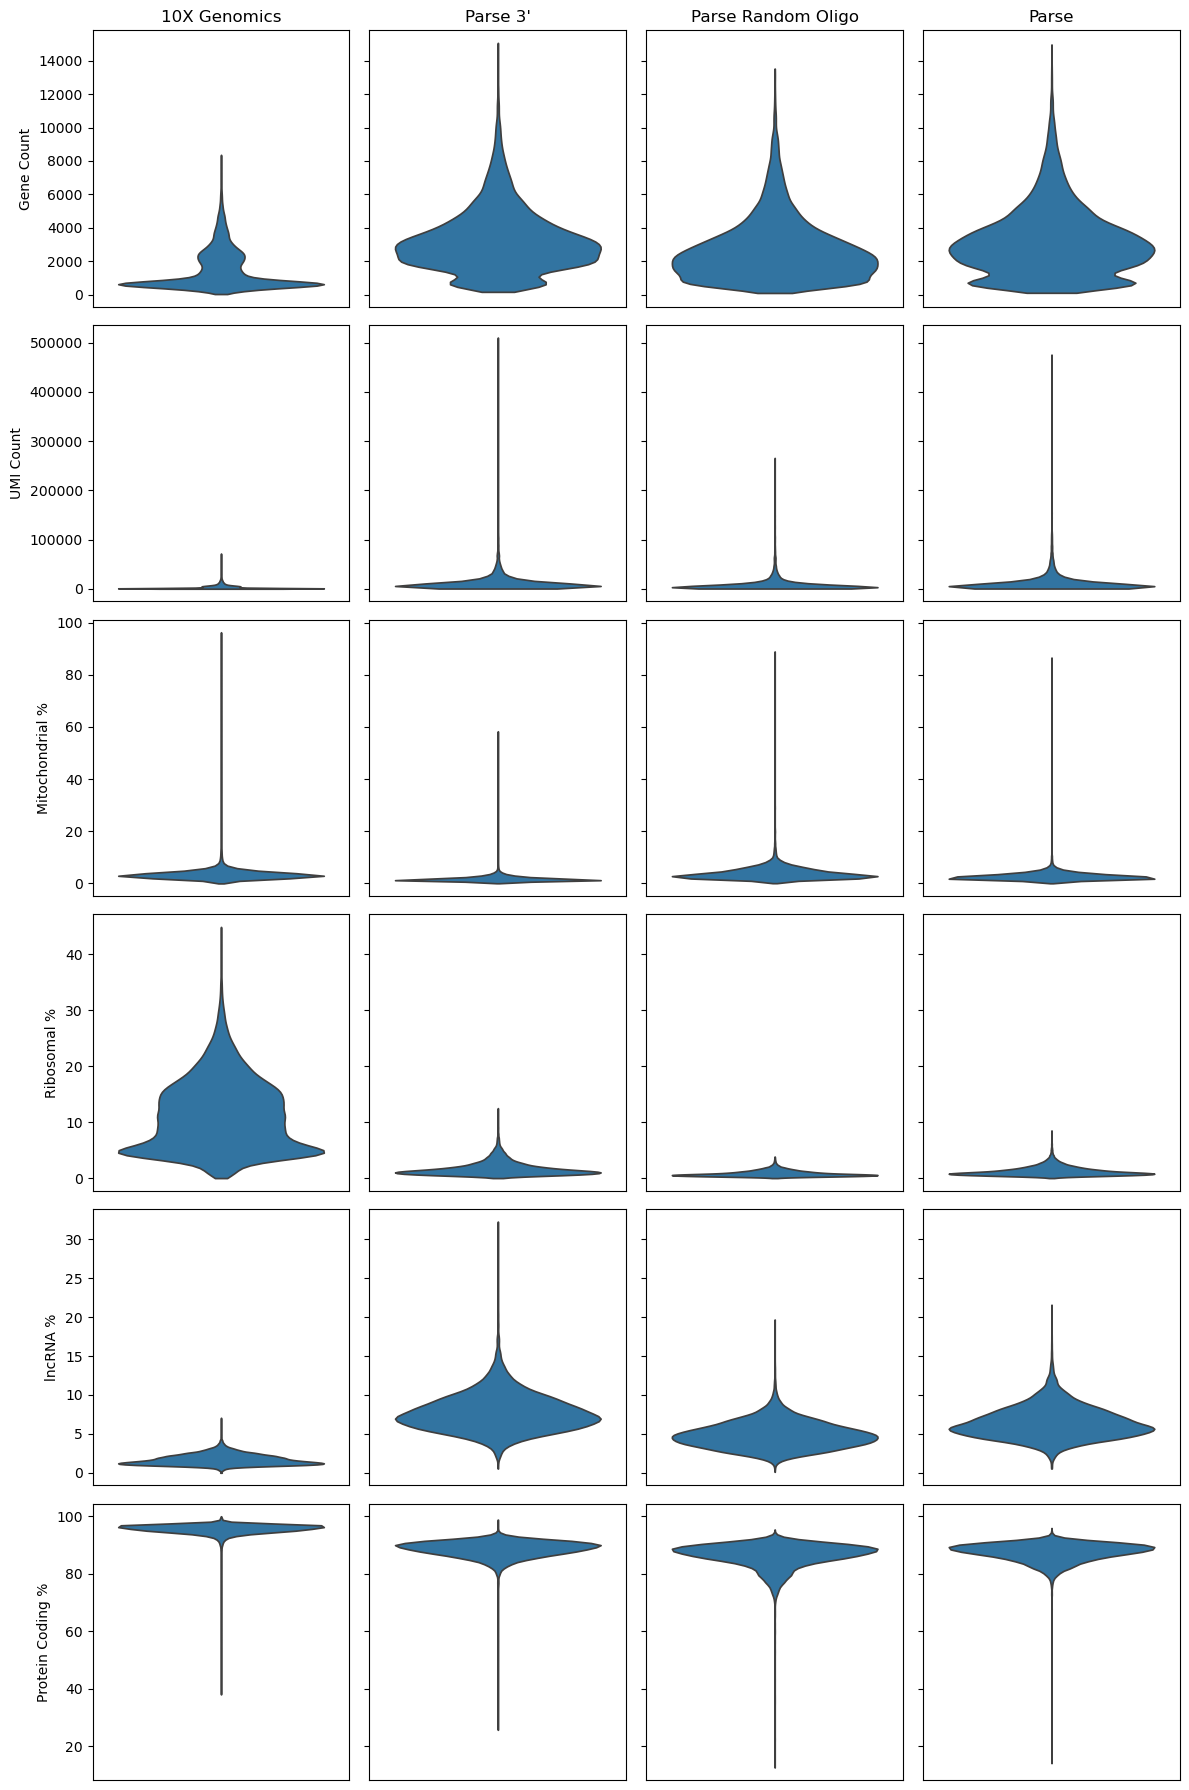

In [15]:
groups = ['n_genes', 'n_counts', 'percent_mito', 'percent_ribo', 'percent_lnc', 'percent_pc']
group_names = ['Gene Count', 'UMI Count', 'Mitochondrial %', 'Ribosomal %', 'lncRNA %', 'Protein Coding %']

plotting.plot_cell_metrics(datasets, groups=groups, group_names=group_names, figsize=(12,18))

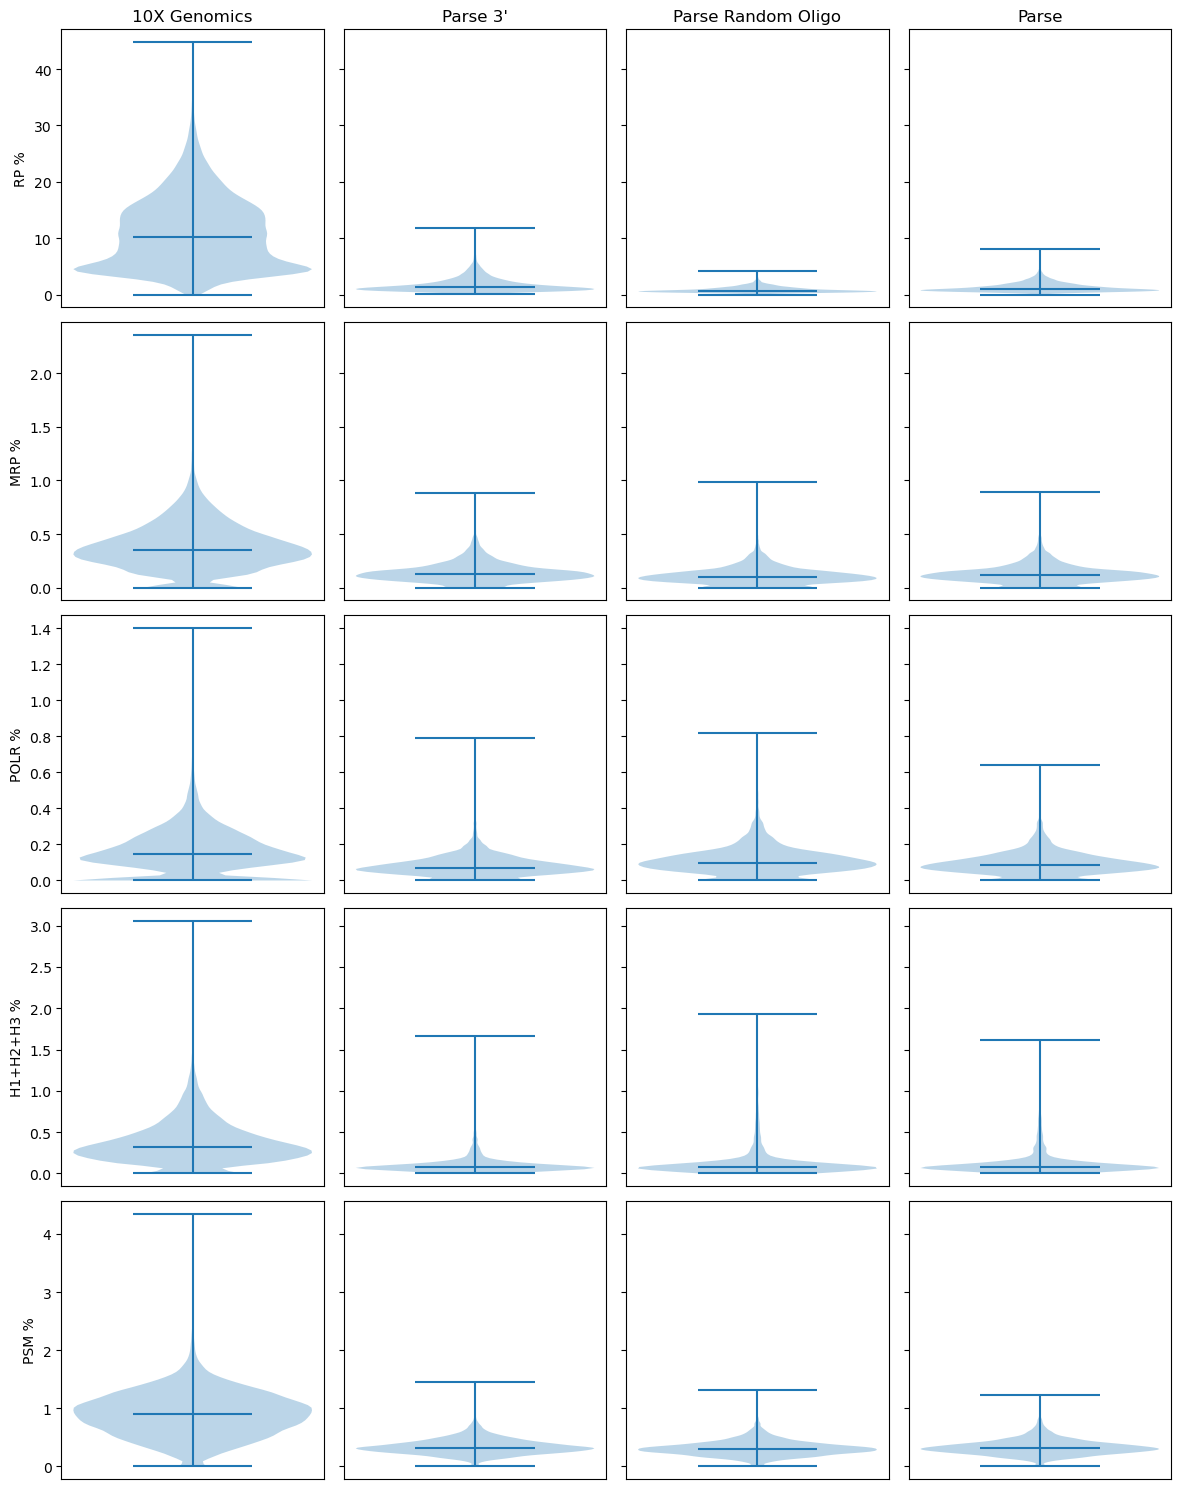

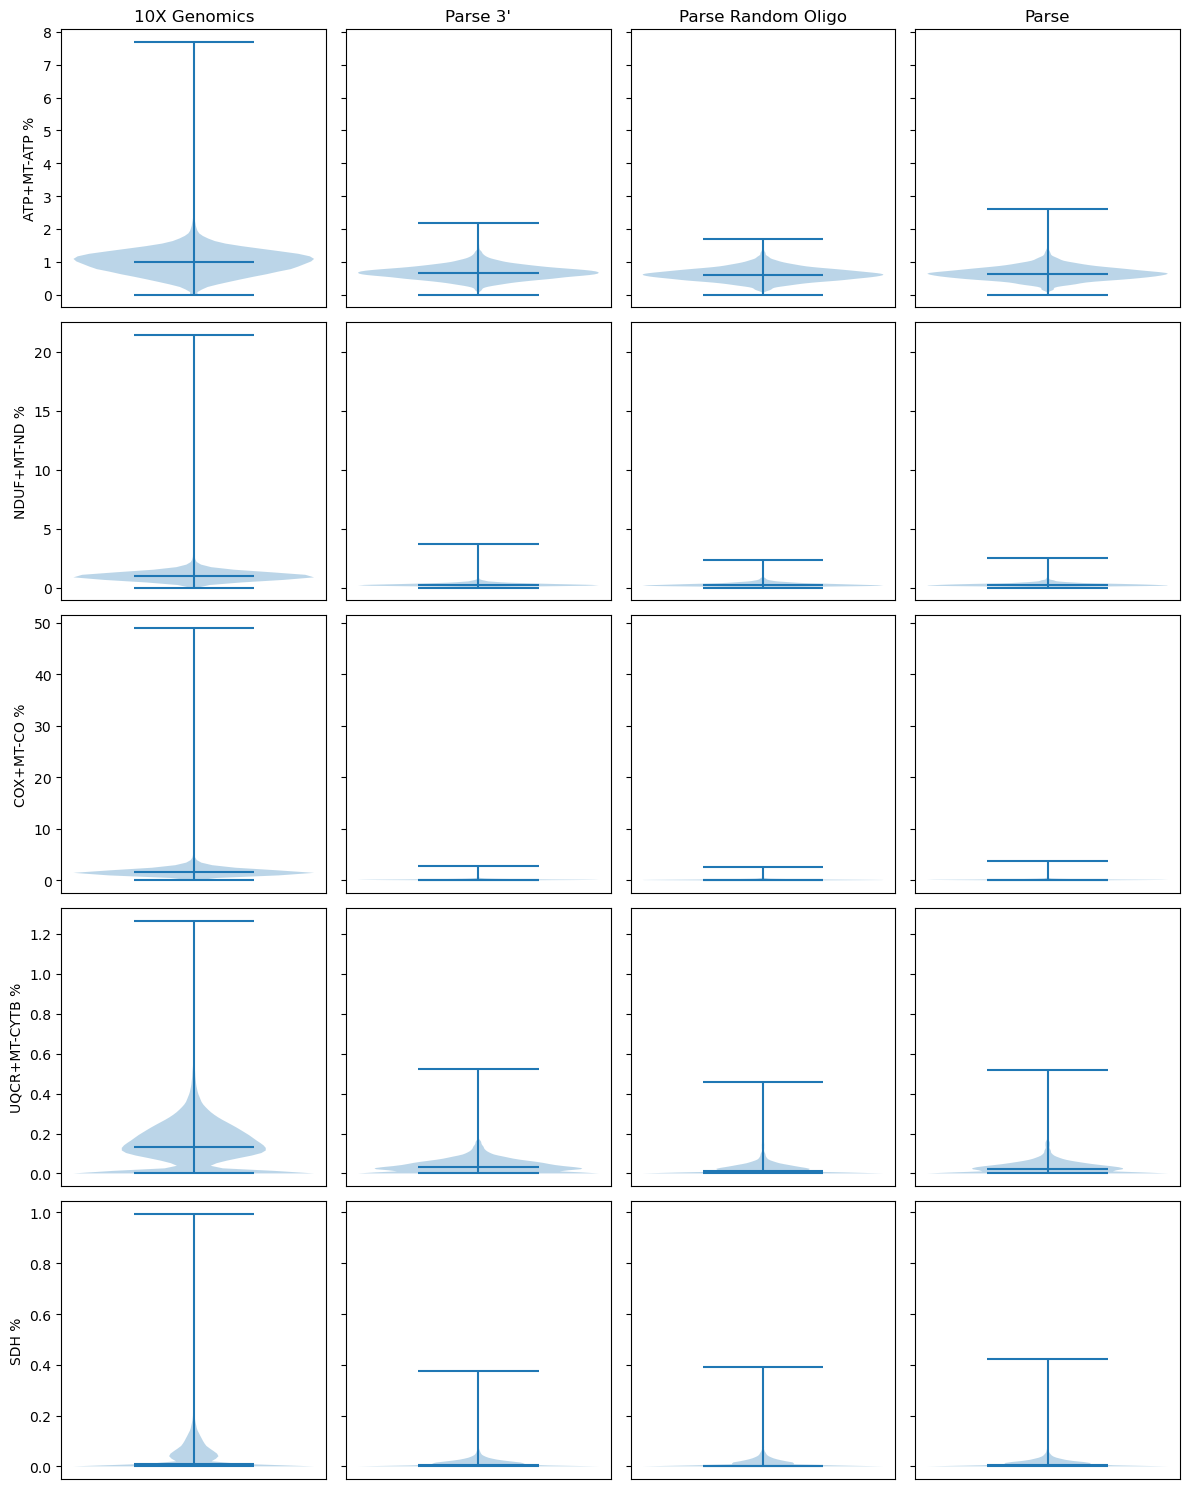

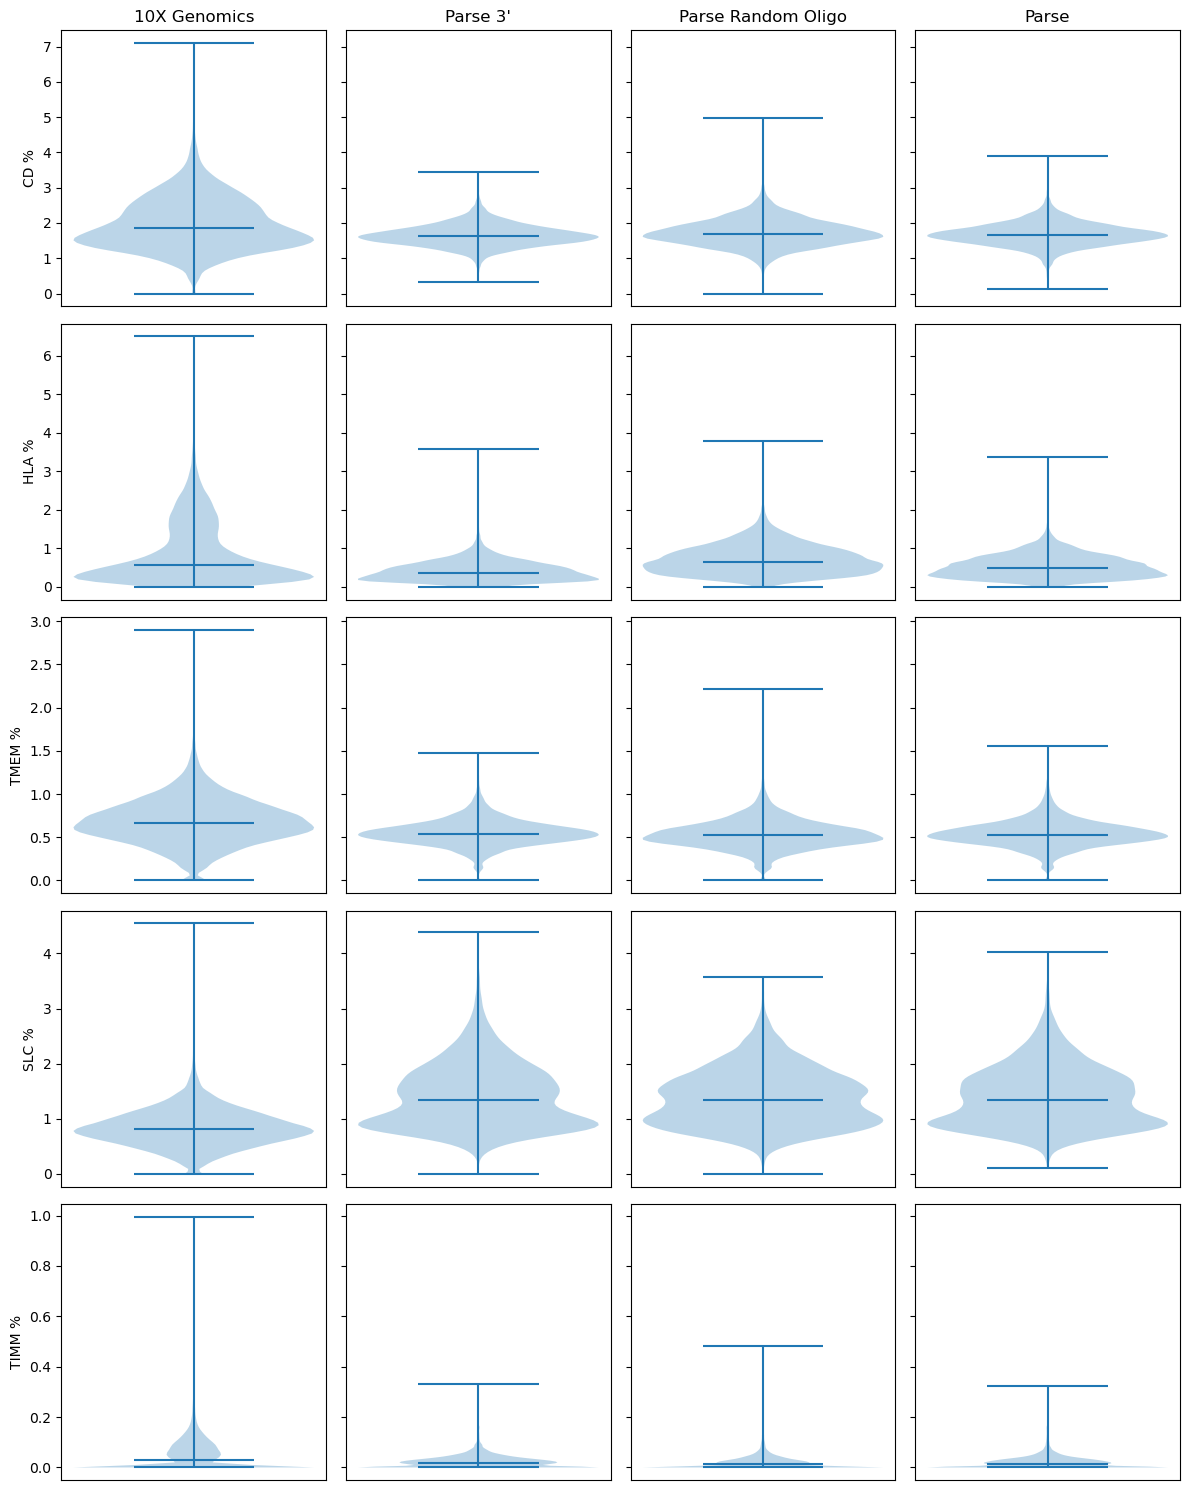

In [16]:
# Transcritptional Gene Family Percentages
plotting.plot_gene_family_percentages(datasets, gene_families=["RP", "MRP", "POLR", "H1+H2+H3", "PSM"])
# OXPHOS Gene Family Percentages
plotting.plot_gene_family_percentages(datasets, gene_families=["ATP+MT-ATP", "NDUF+MT-ND", "COX+MT-CO", "UQCR+MT-CYTB", "SDH"])
# cell suface and transmembrane protein gene family percentages
plotting.plot_gene_family_percentages(datasets, gene_families=["CD", "HLA", "TMEM", "SLC", "TIMM"])

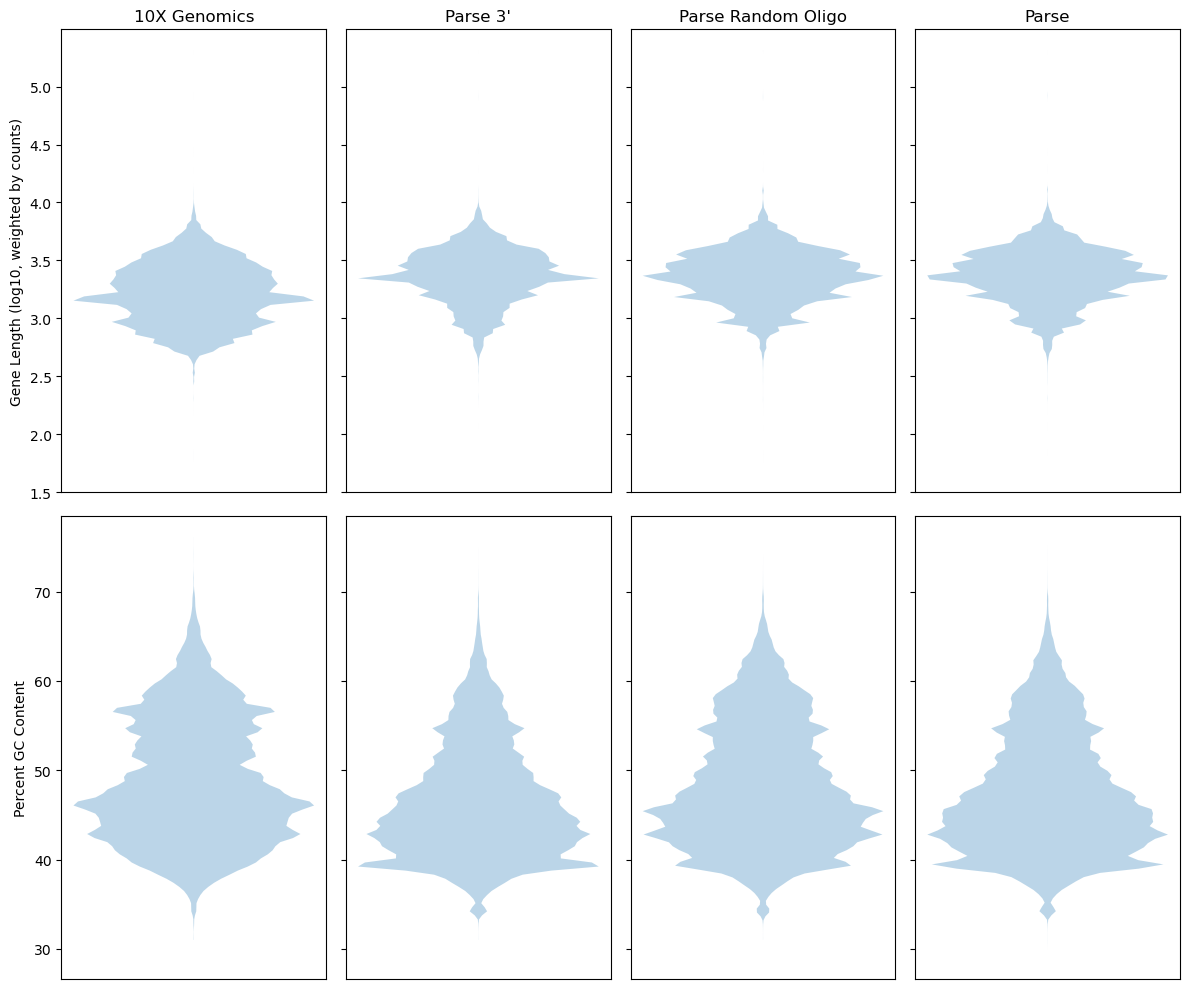

In [17]:
plotting.plot_gene_metrics(datasets, sample_size = 1000000)

# Read/Gene Comparisons

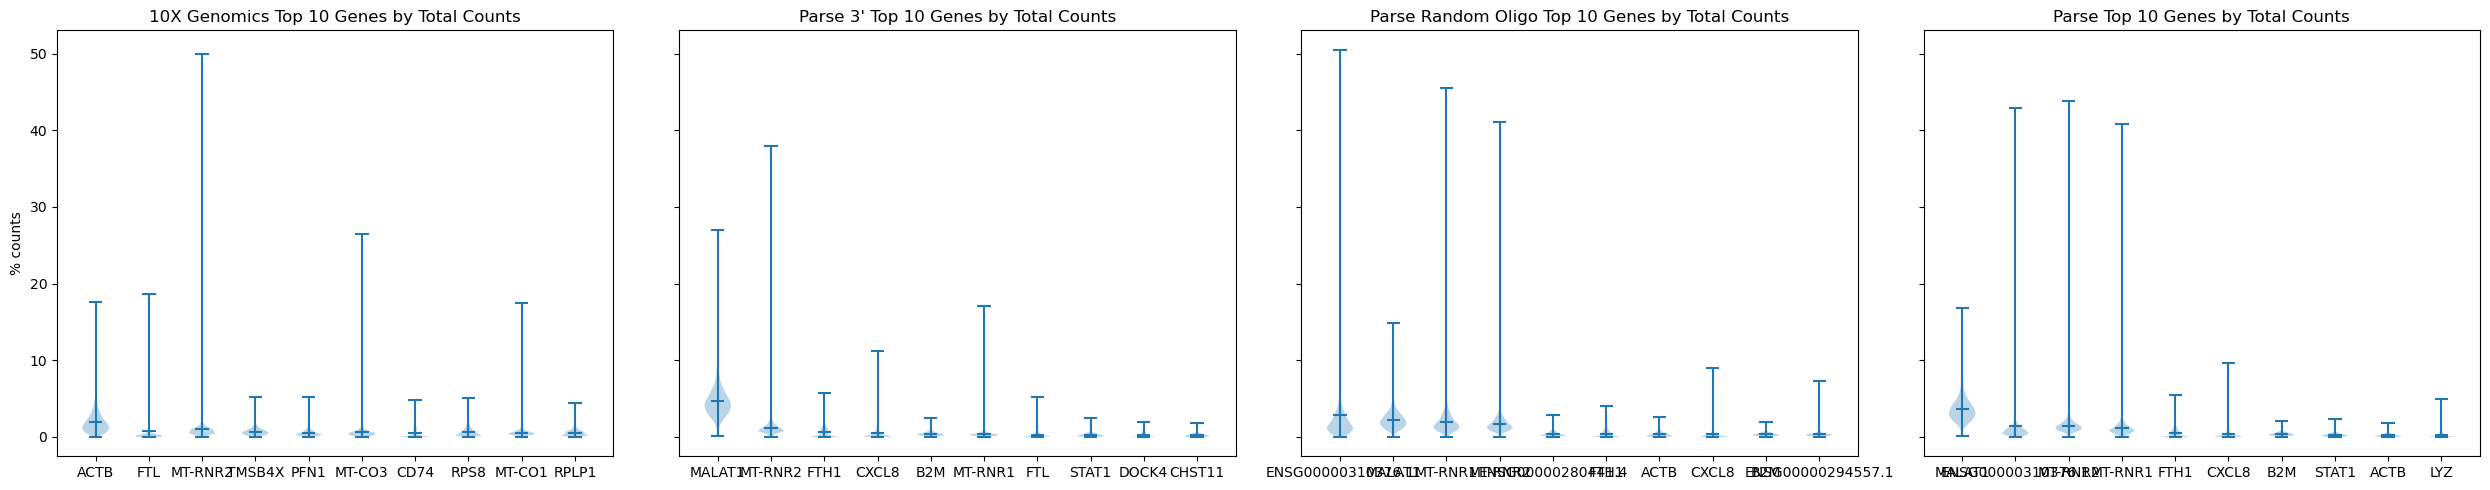

In [18]:
fig, ax = plt.subplots(1, 4, figsize=(25,5), sharey=True)

for i, data in enumerate(datasets):
    plotting.top_gene_counts(ax[i], data)

ax[0].set_ylabel("% counts")

plt.tight_layout()
plt.show()

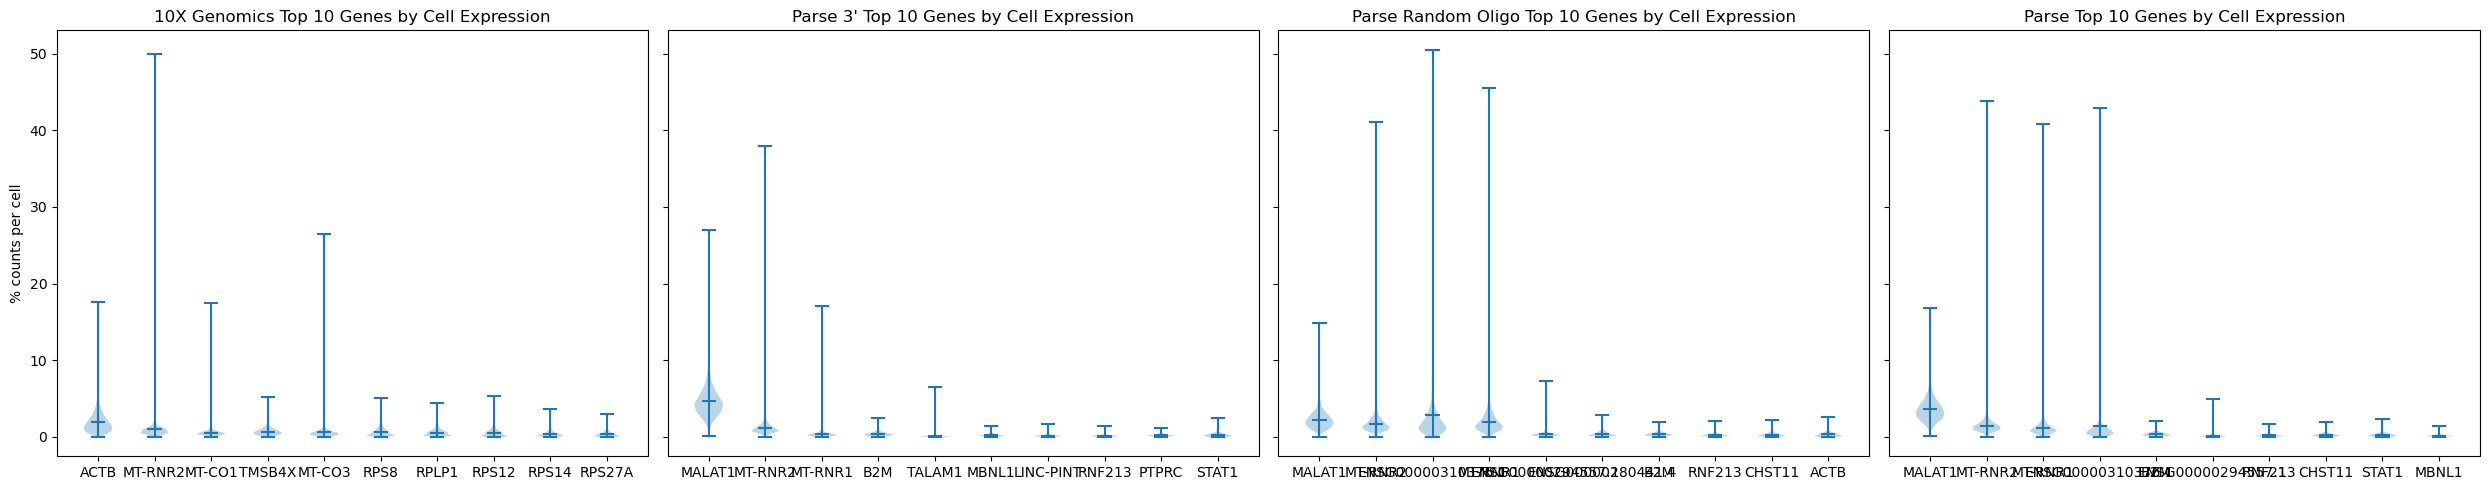

In [19]:
fig, ax = plt.subplots(1, 4, figsize=(25,5), sharey=True)
for i, data in enumerate(datasets):
    plotting.top_gene_cell_expression(ax[i], data)

ax[0].set_ylabel("% counts per cell")

plt.tight_layout()
plt.show()

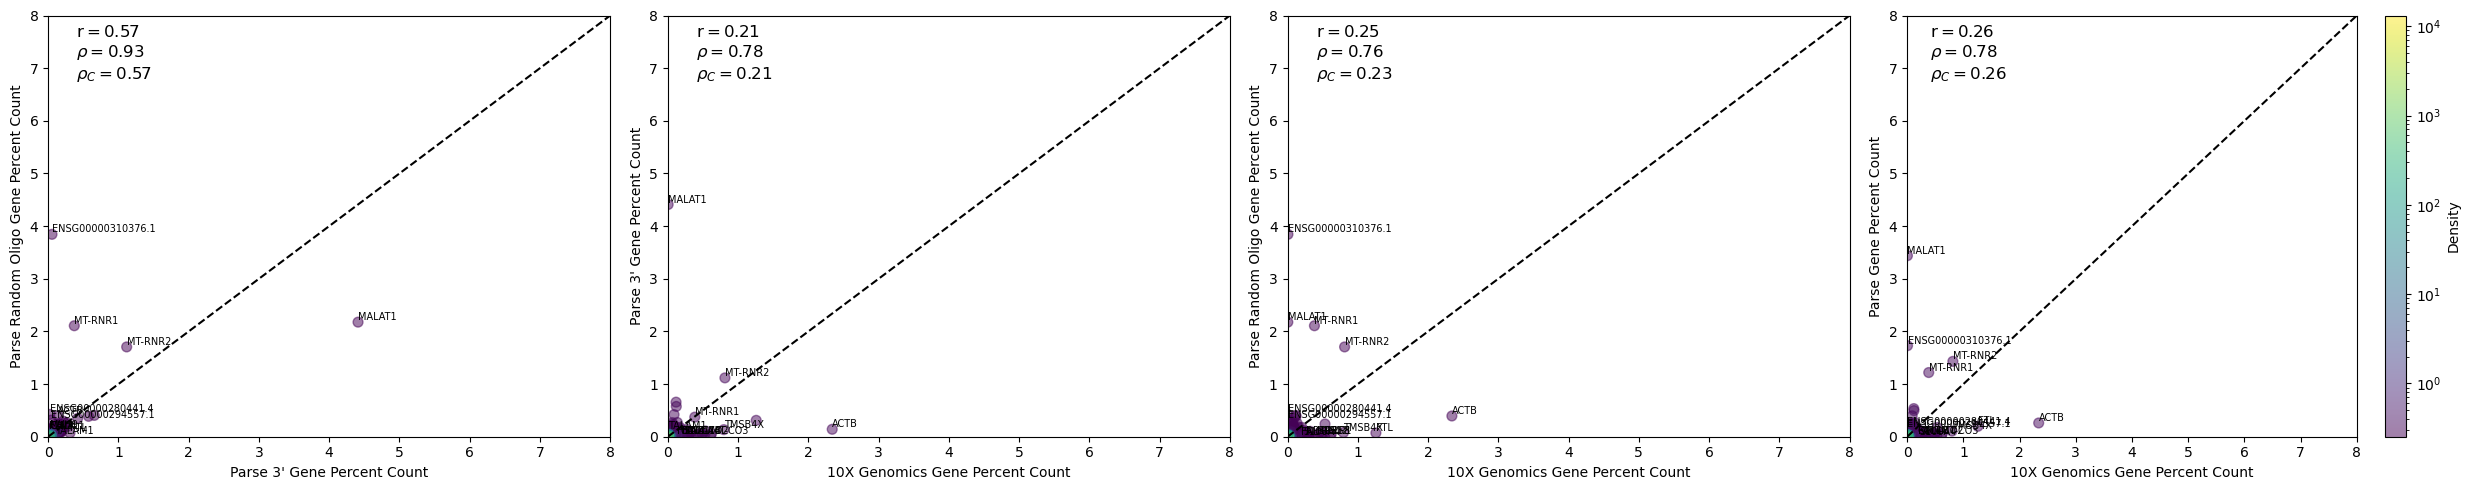

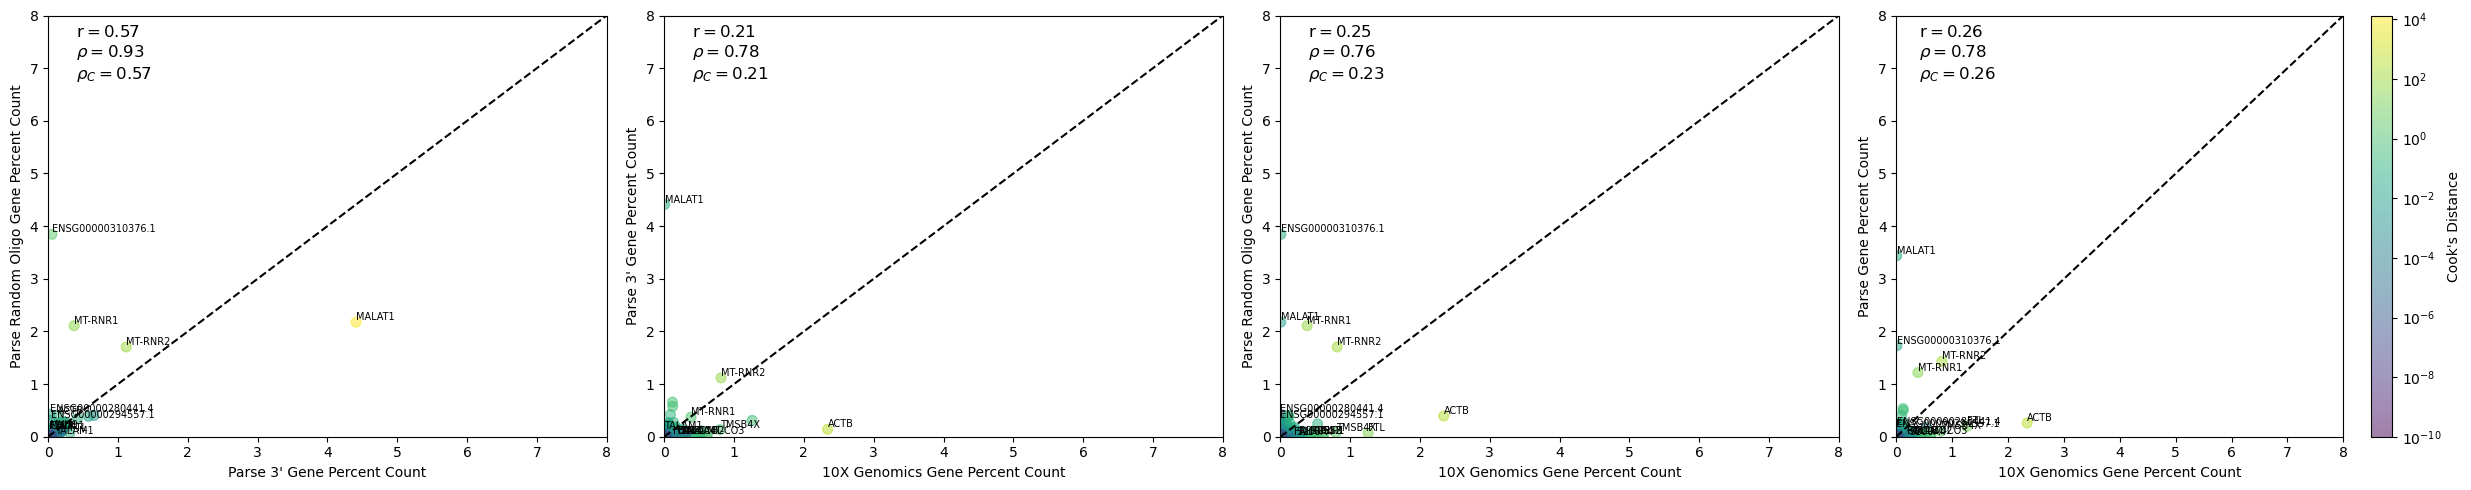

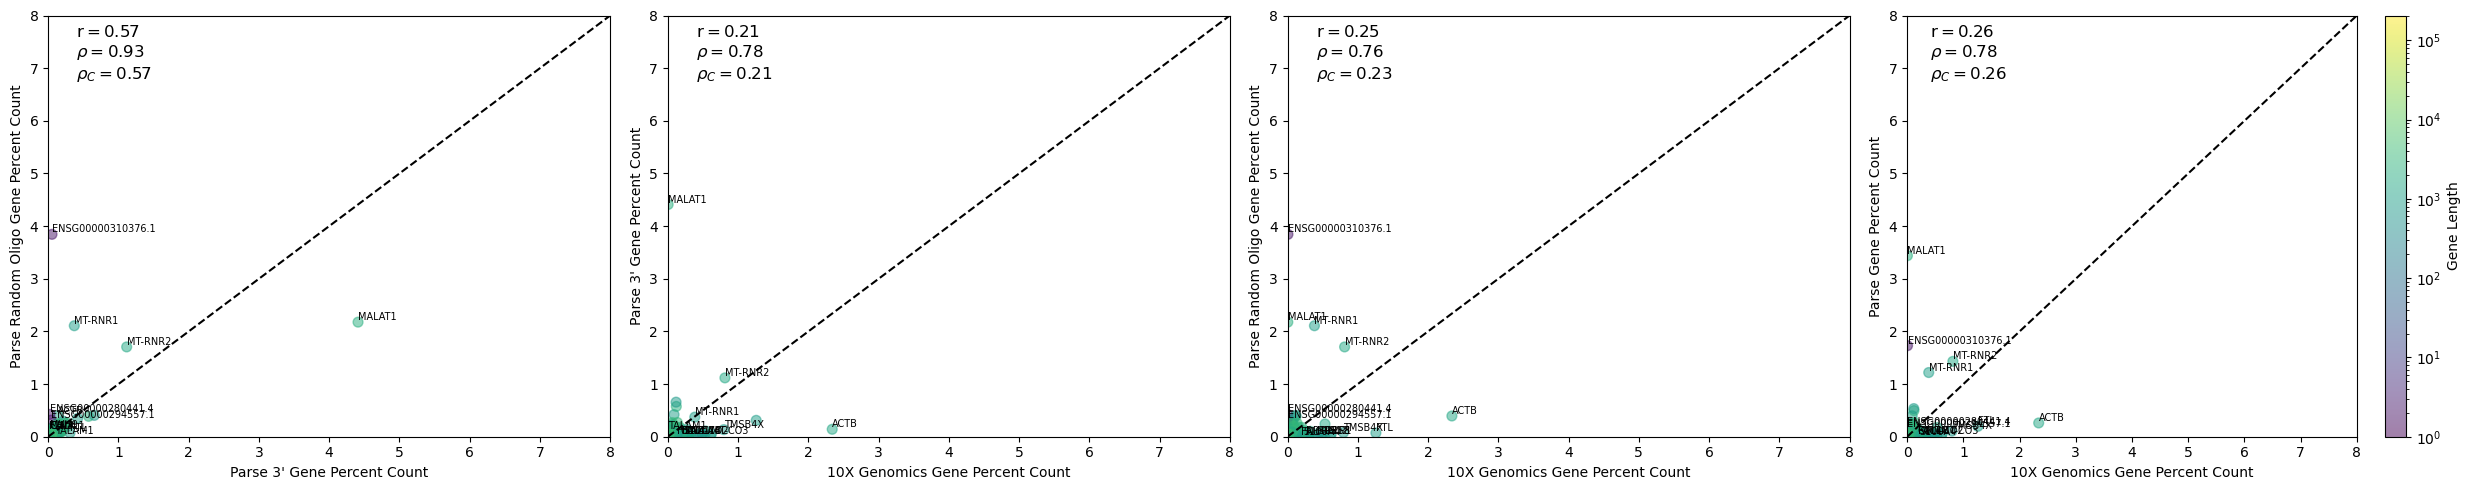

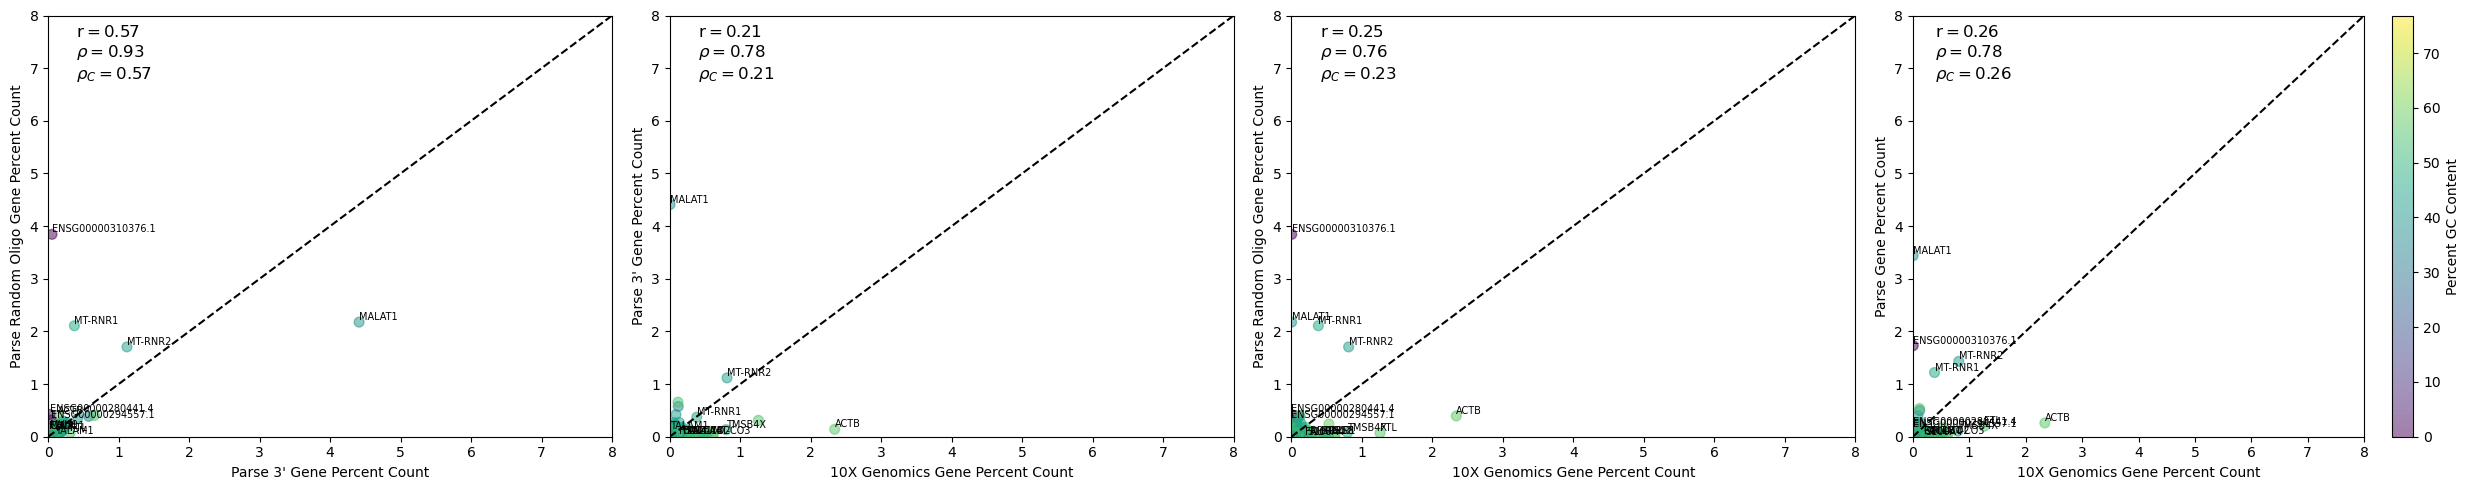

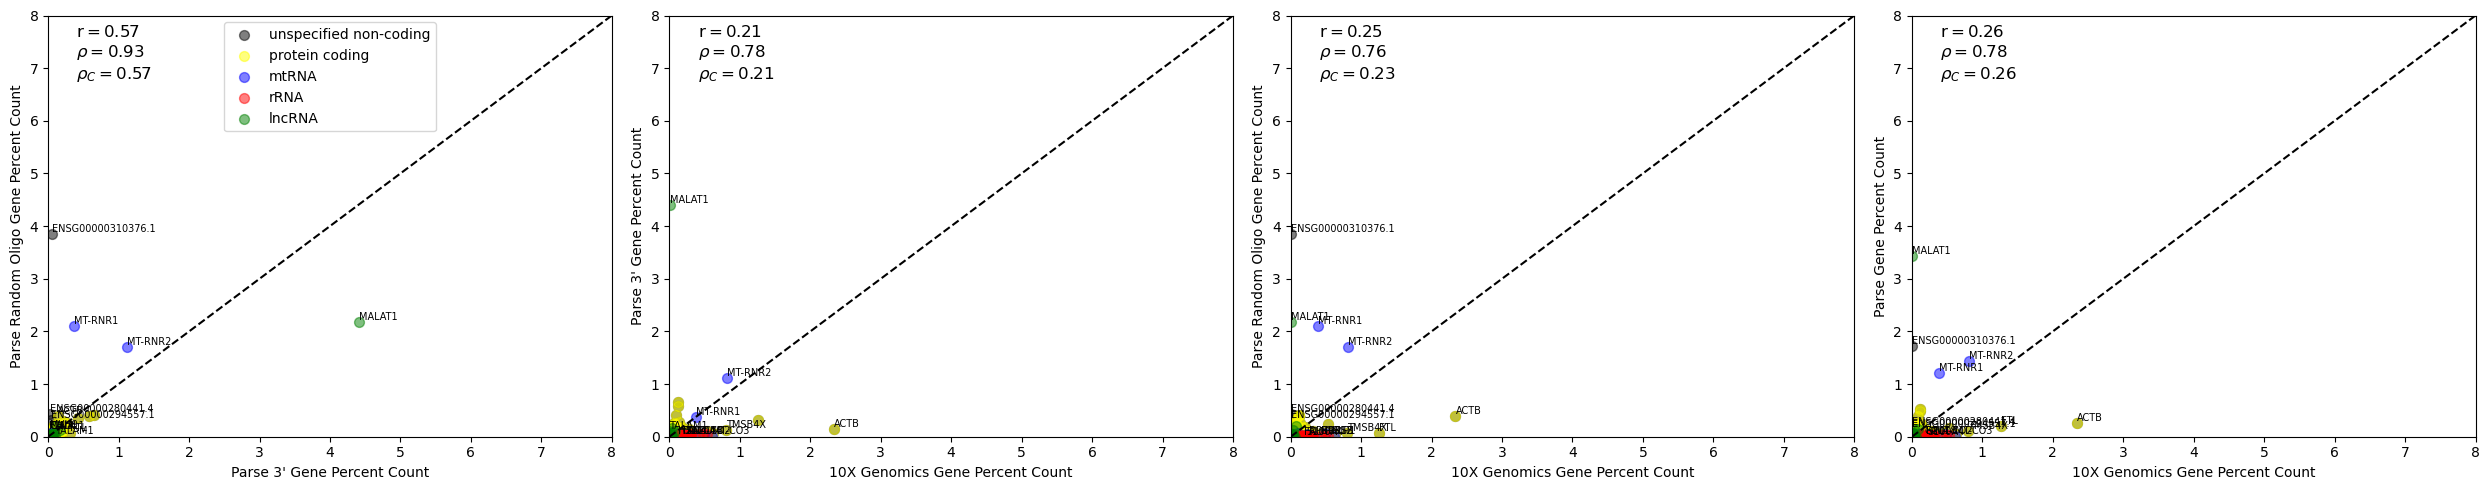

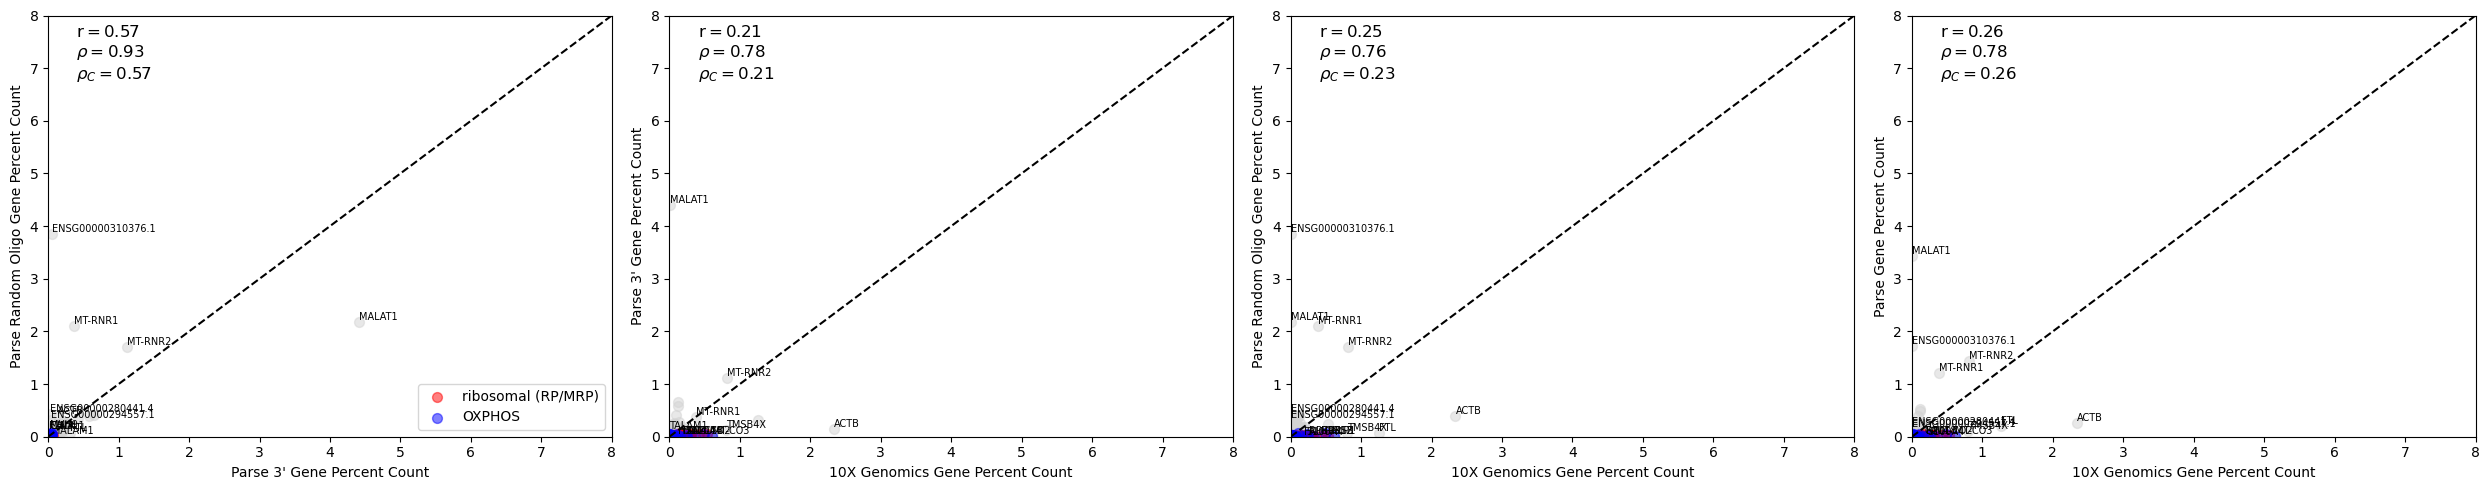

In [20]:
compare_names, compare_dfs = plotting.compare(datasets, 8)

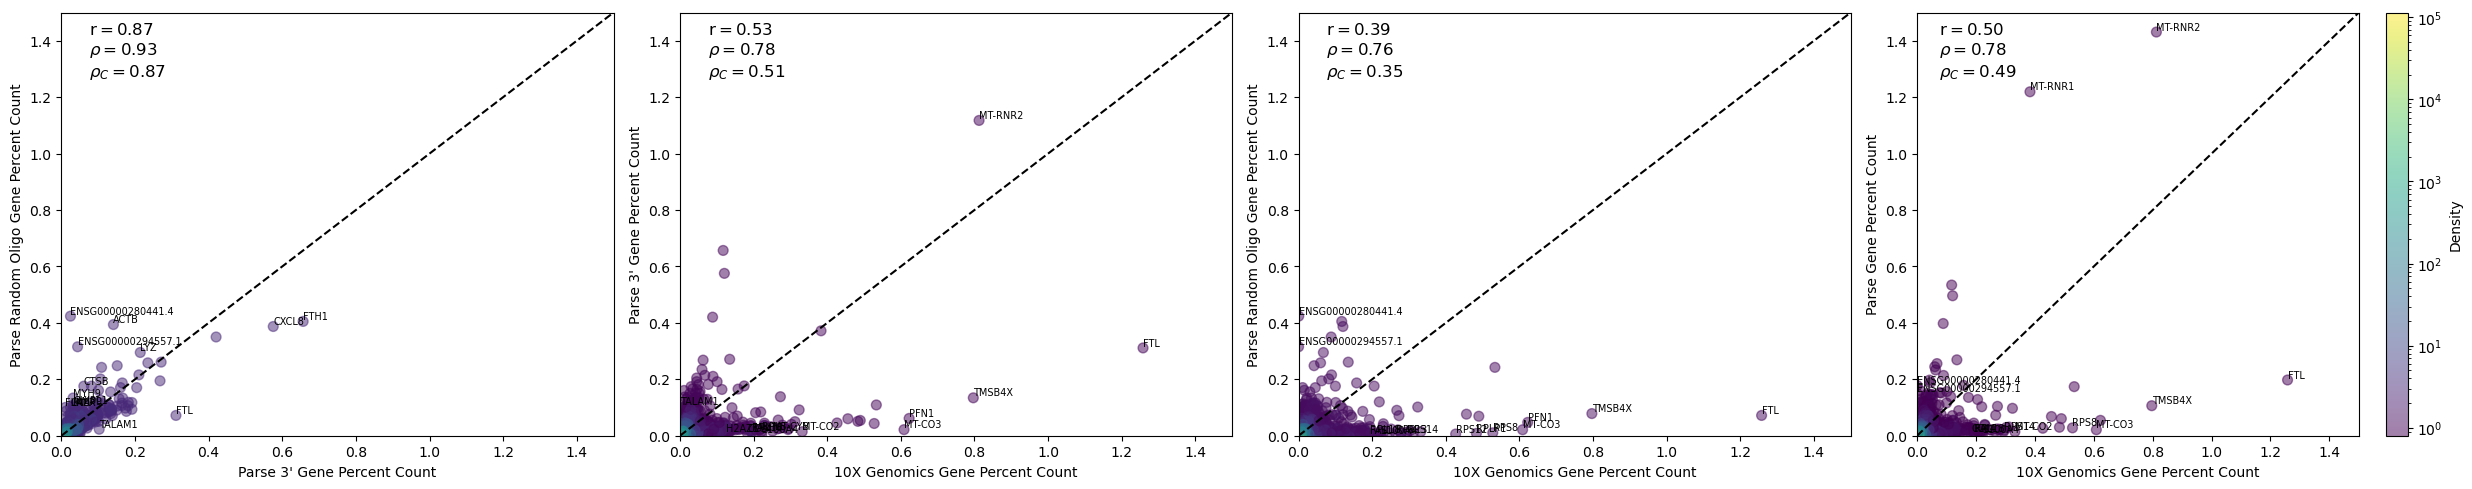

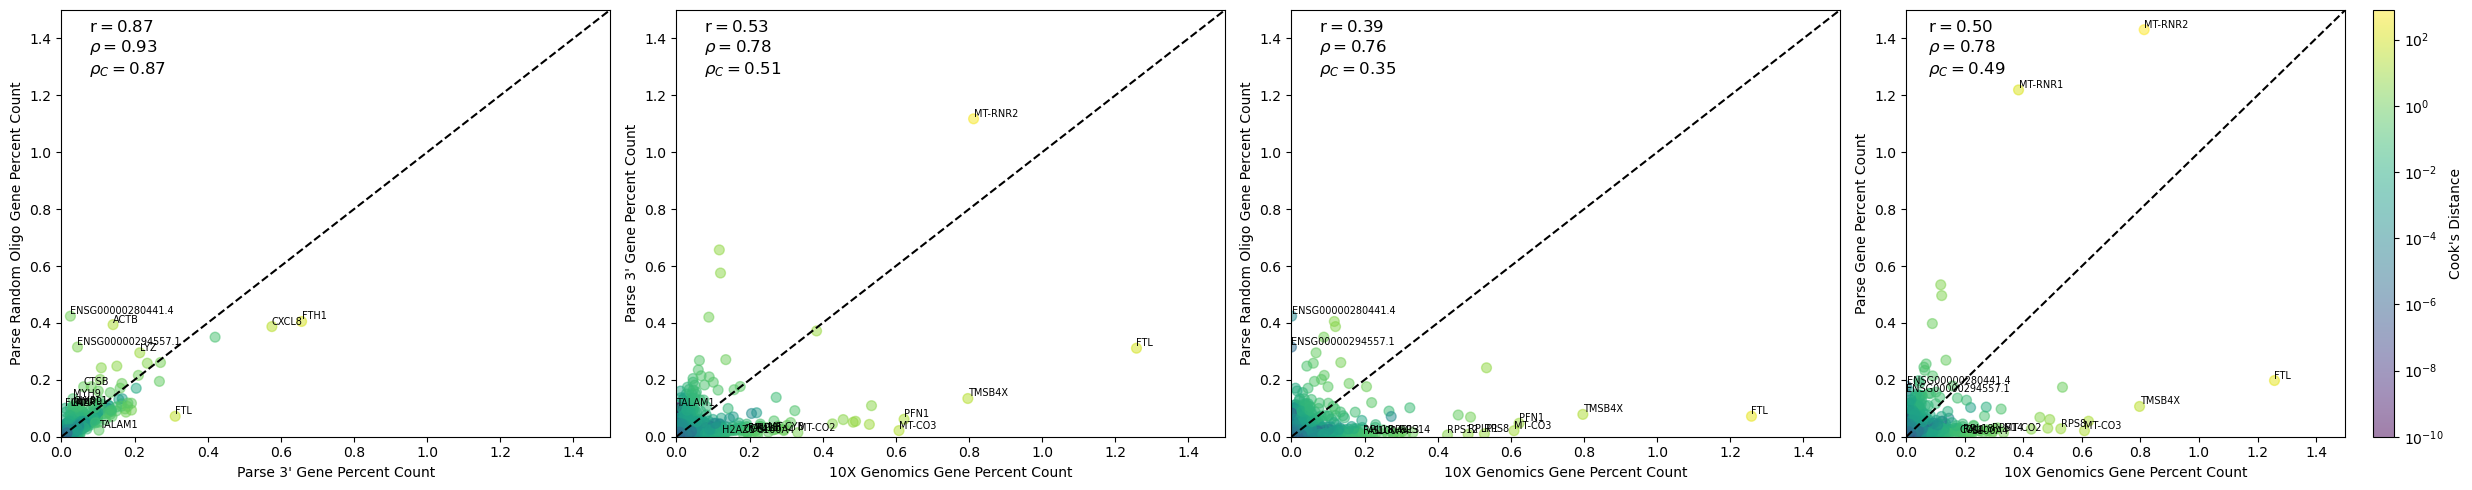

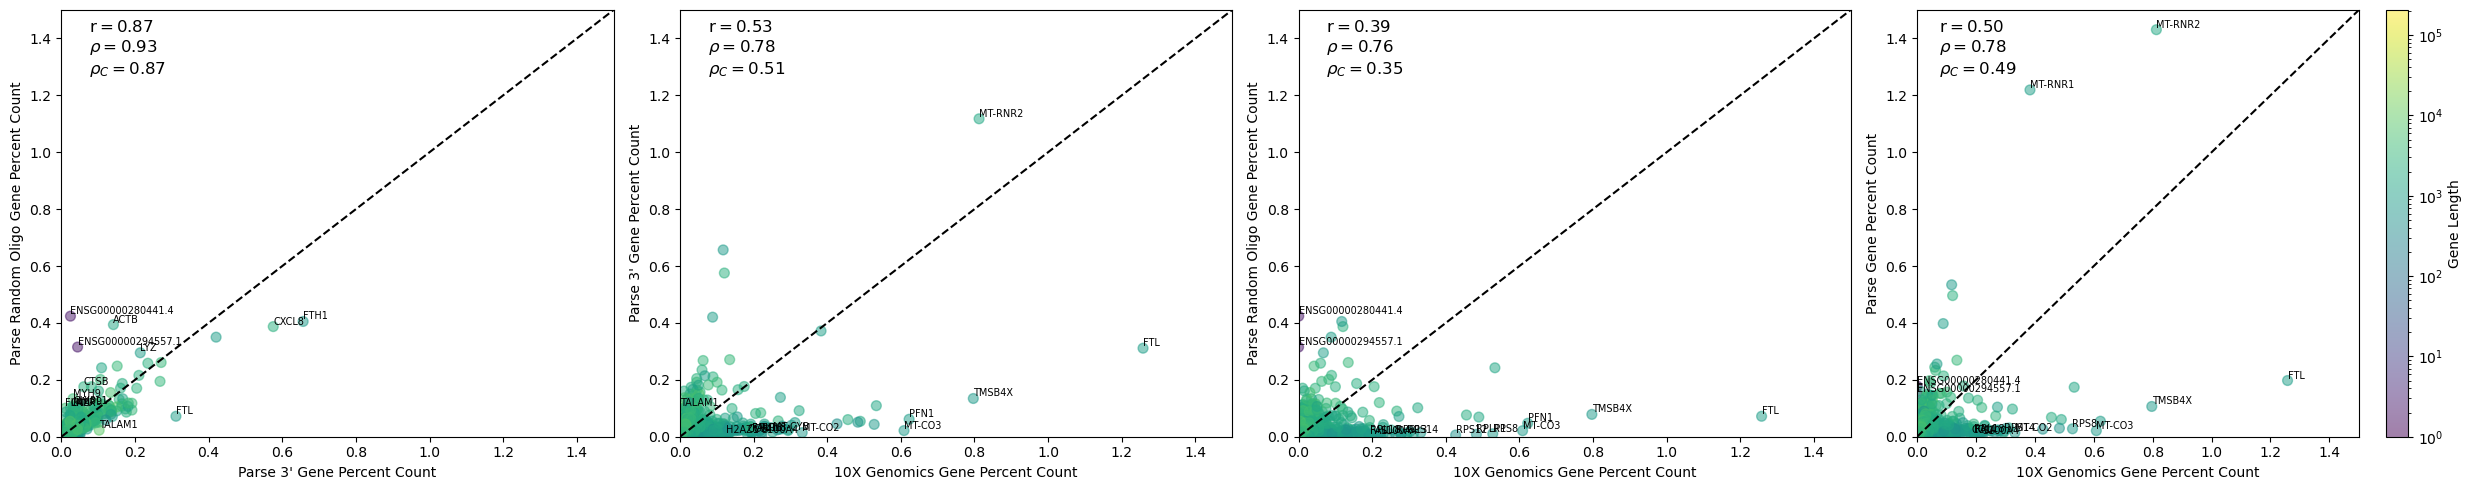

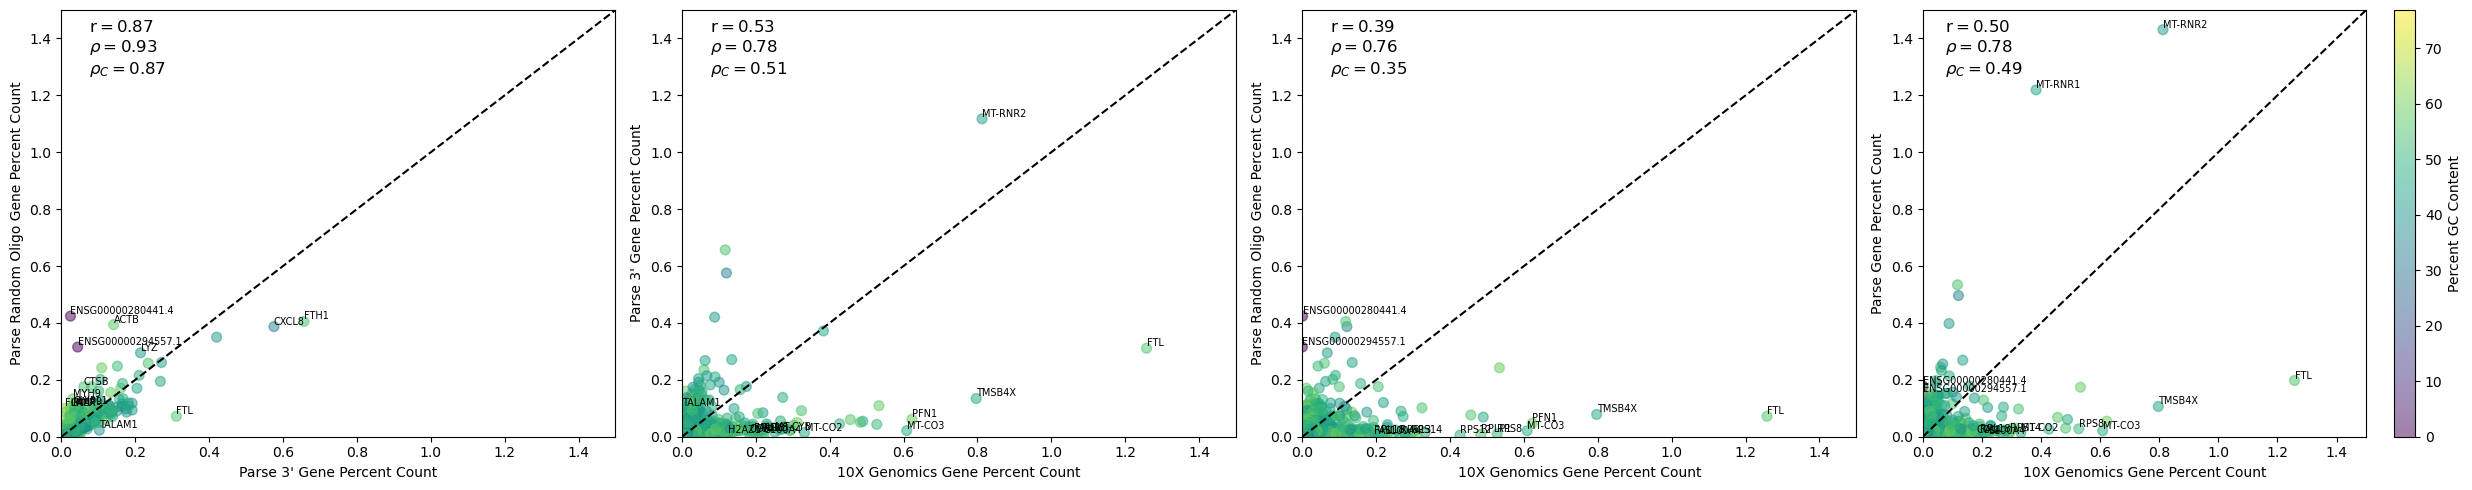

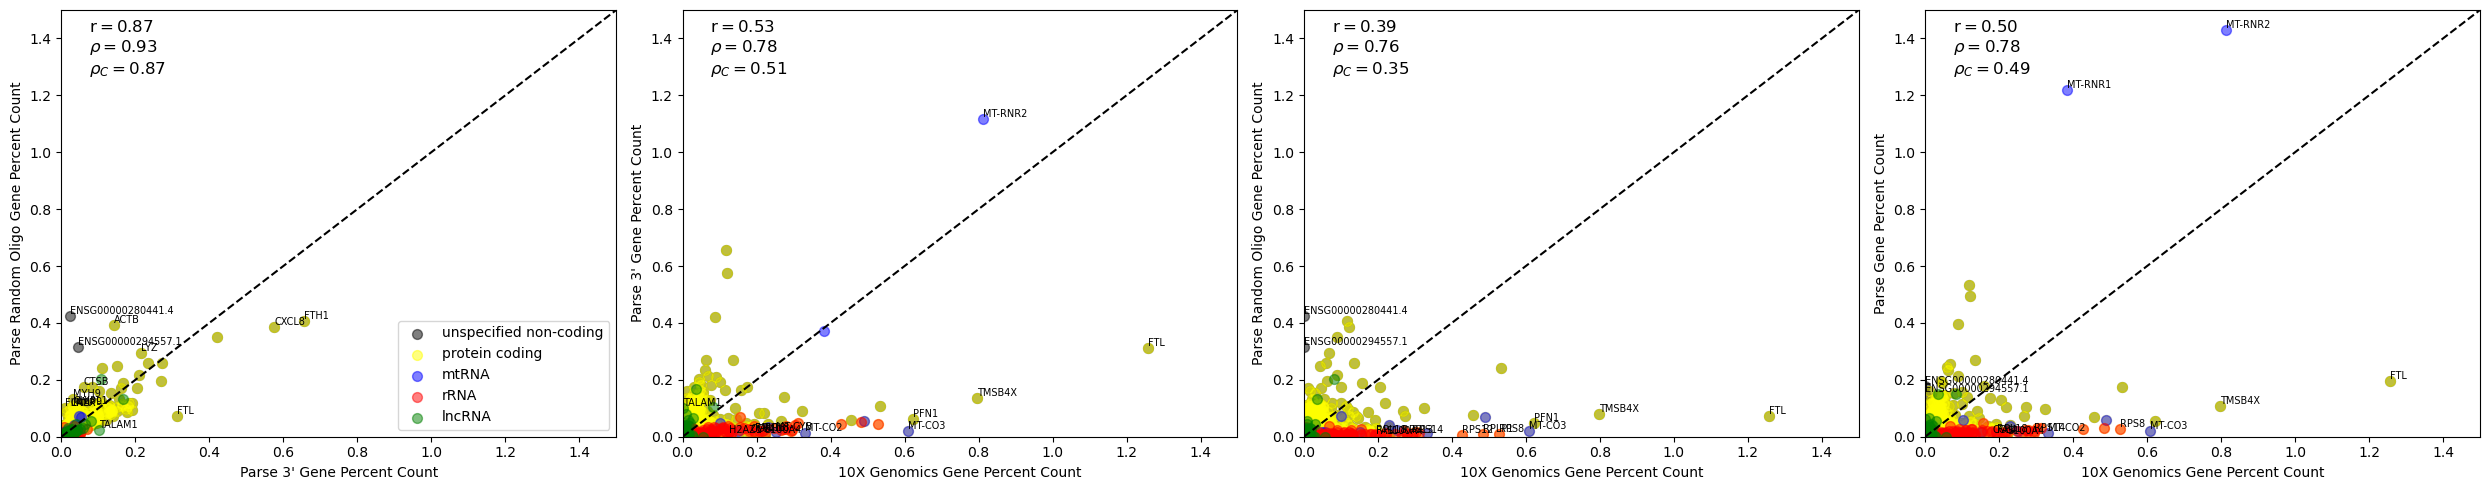

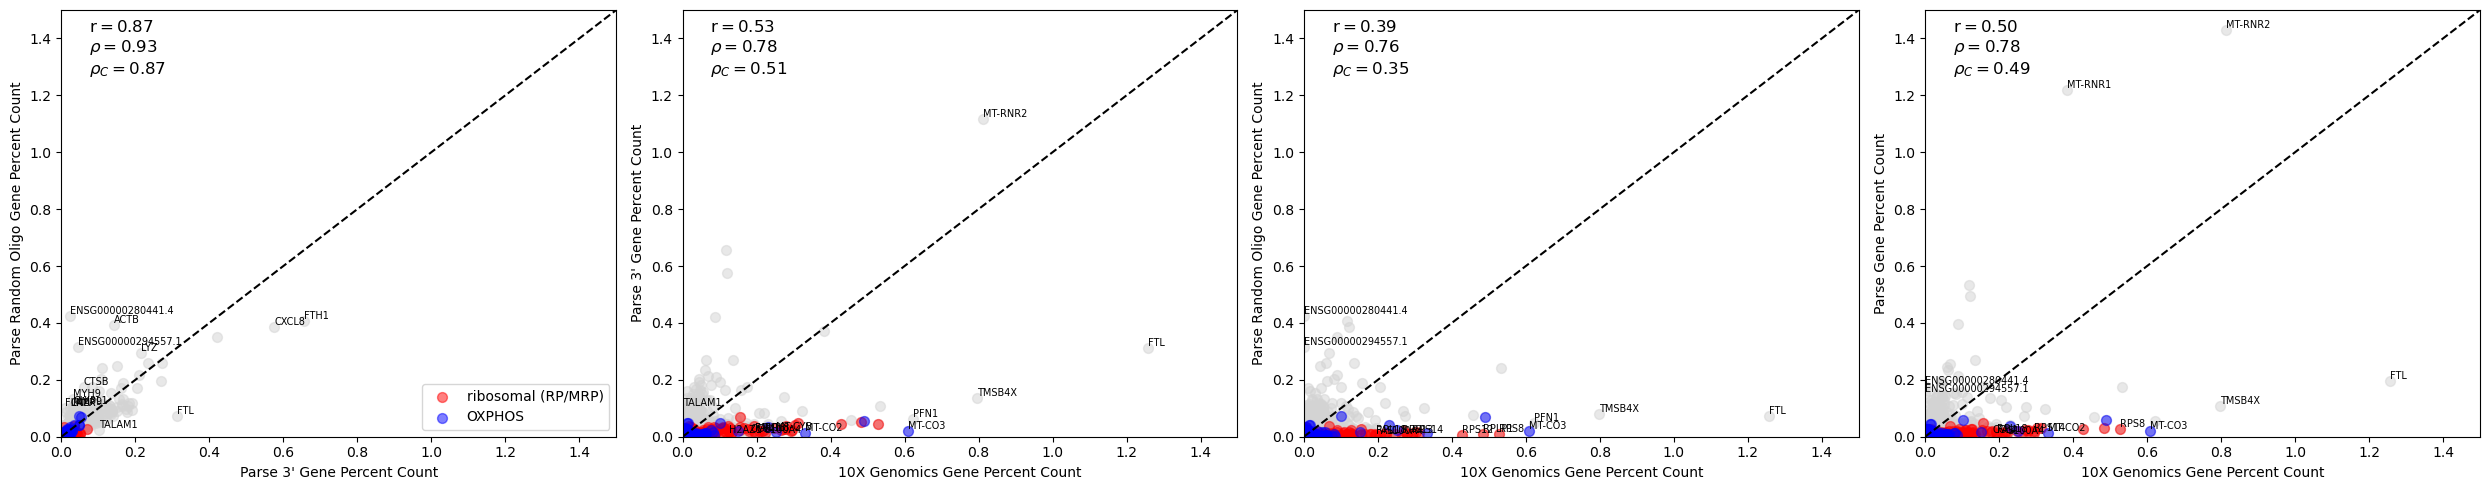

In [21]:
_, _ = plotting.compare(datasets, 1.5)

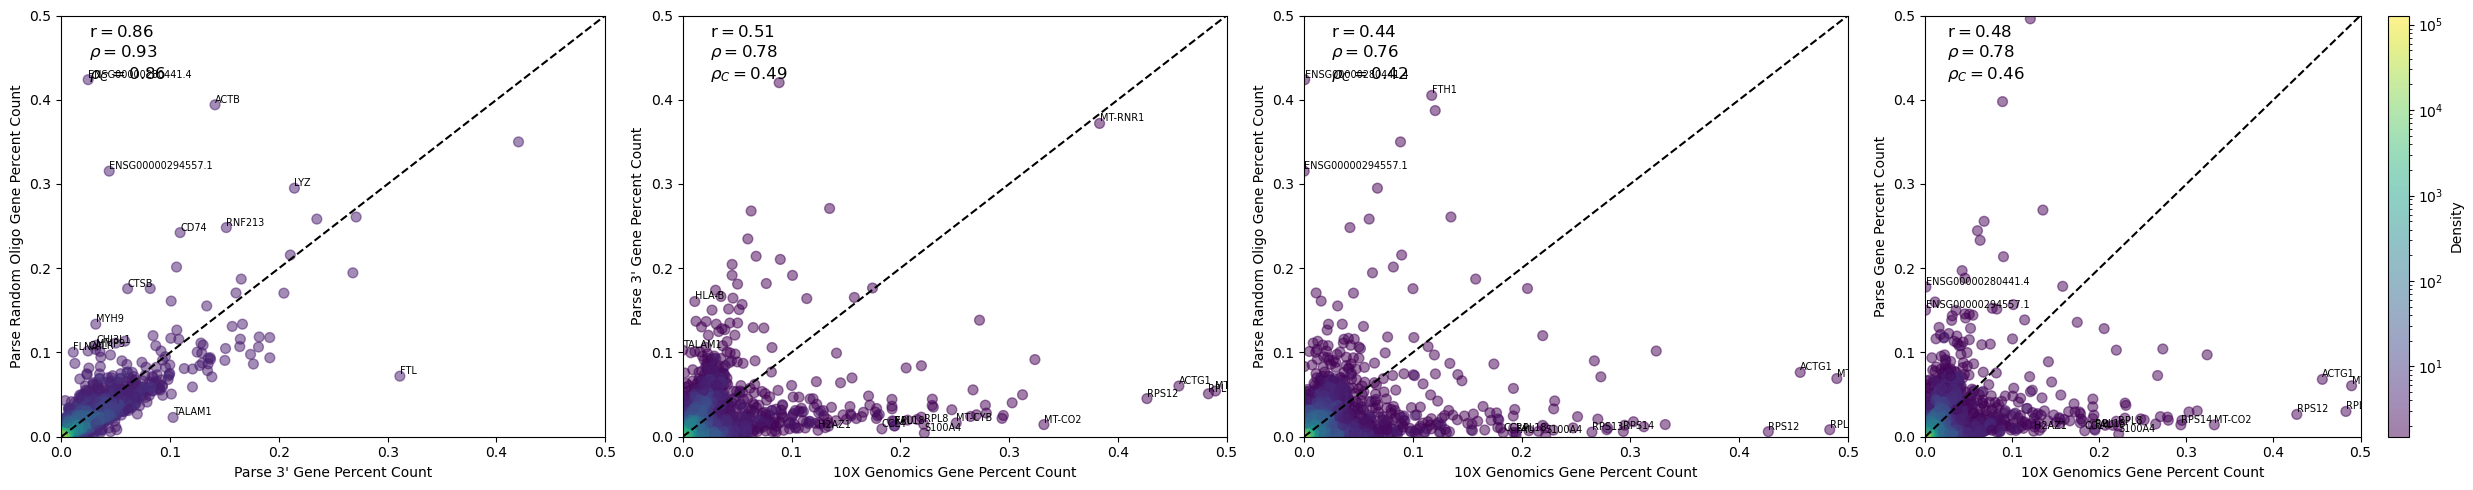

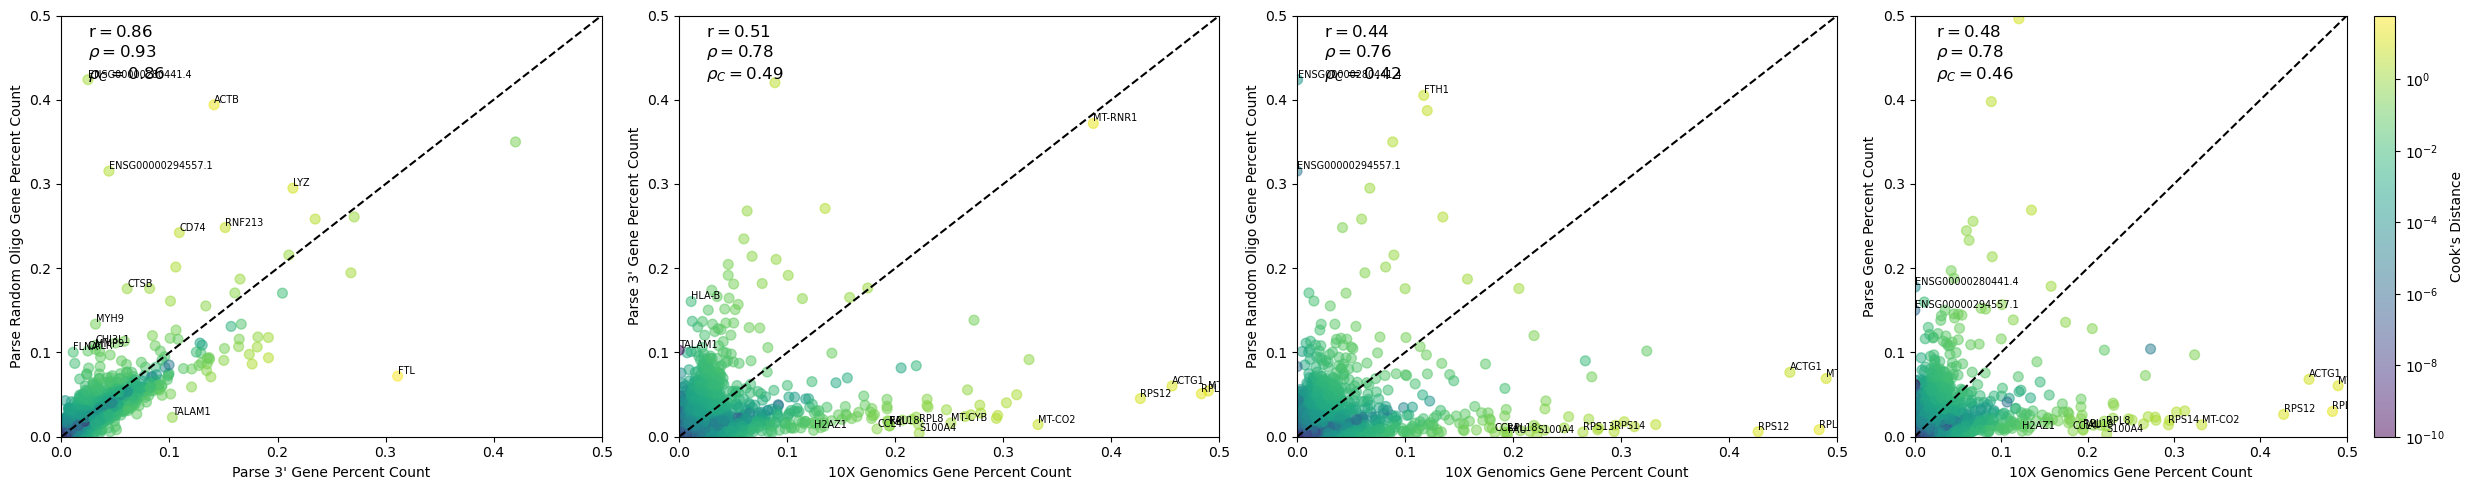

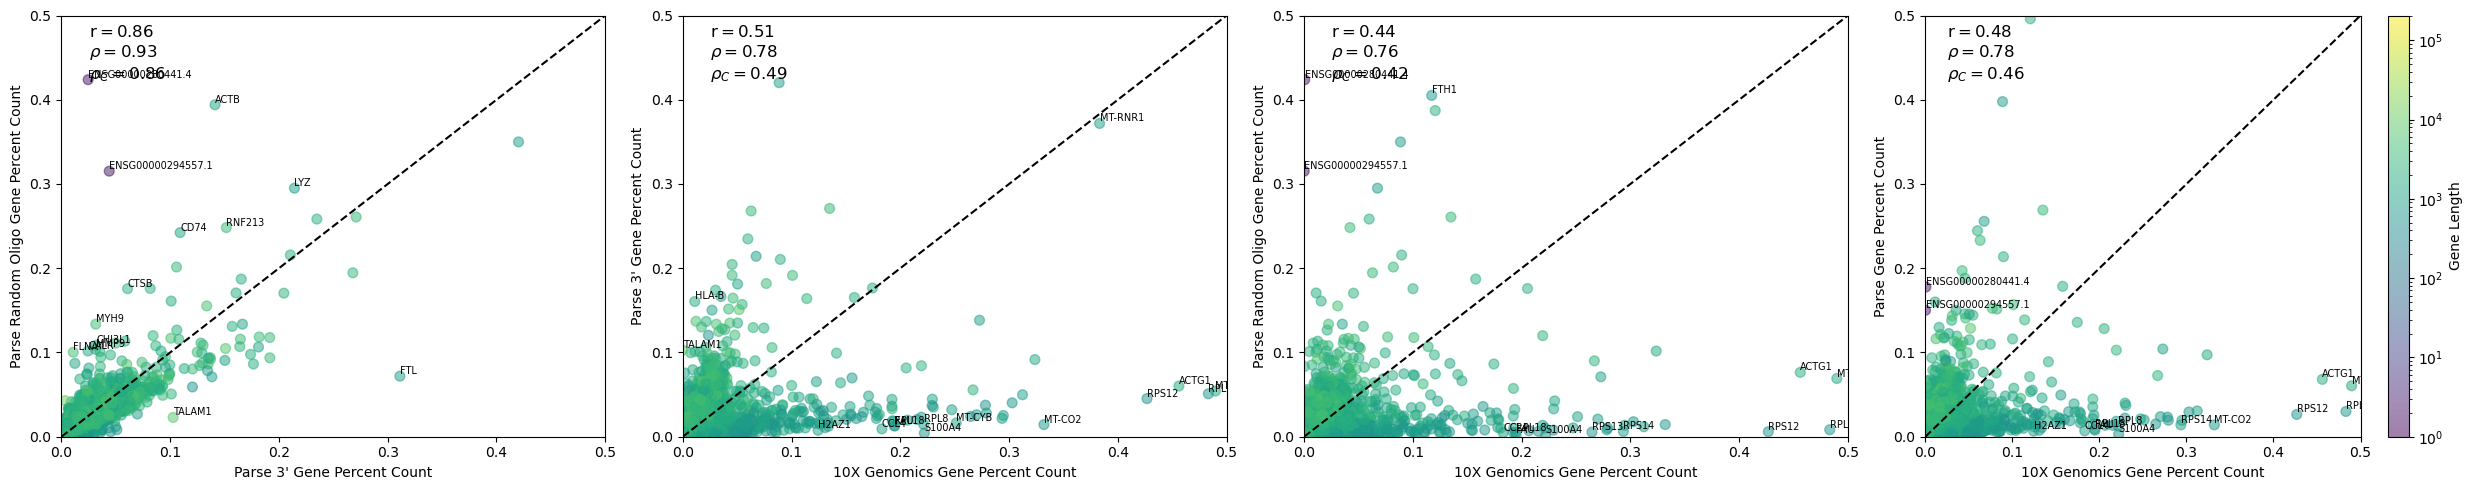

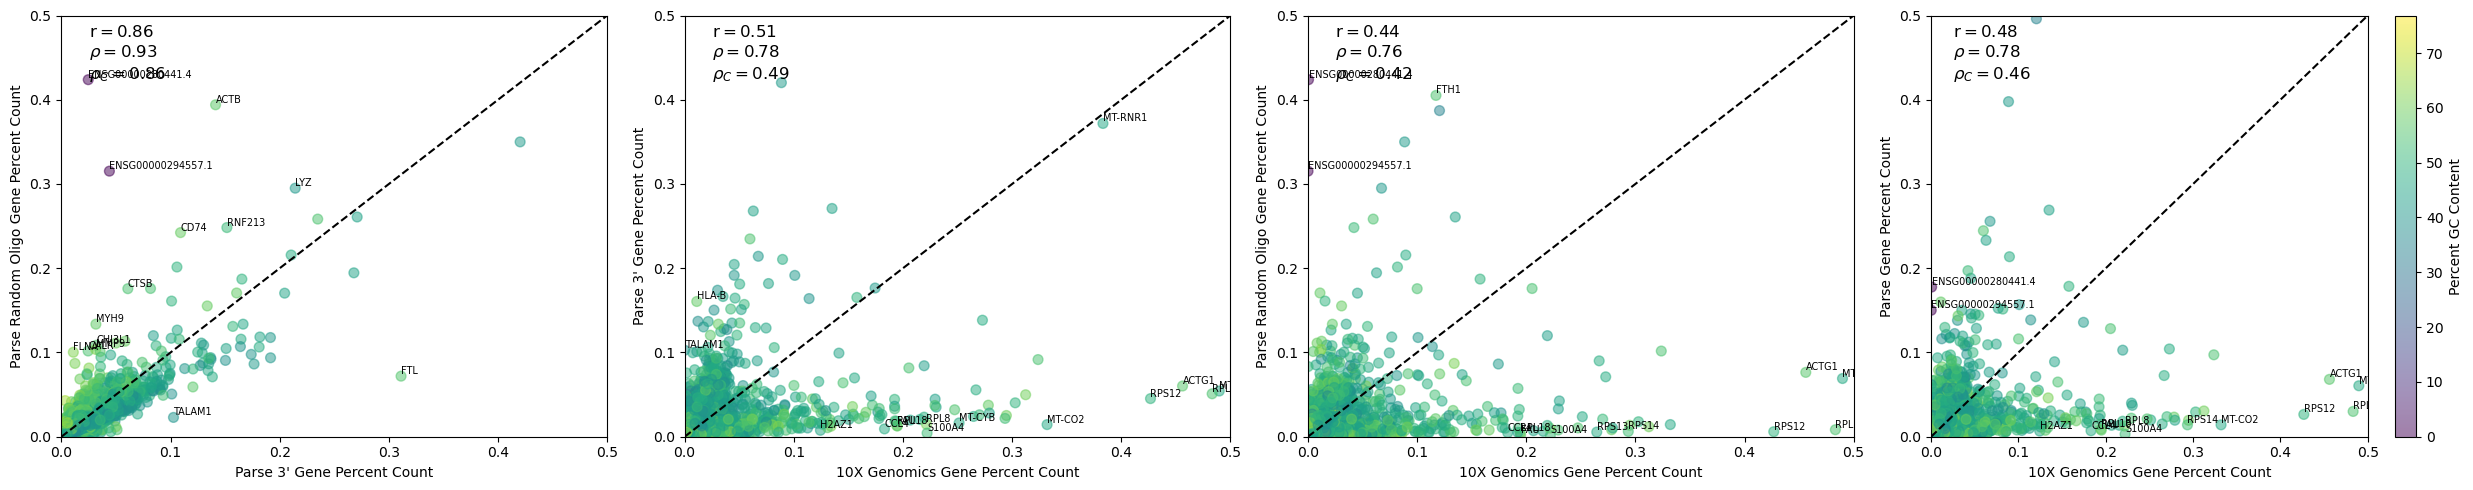

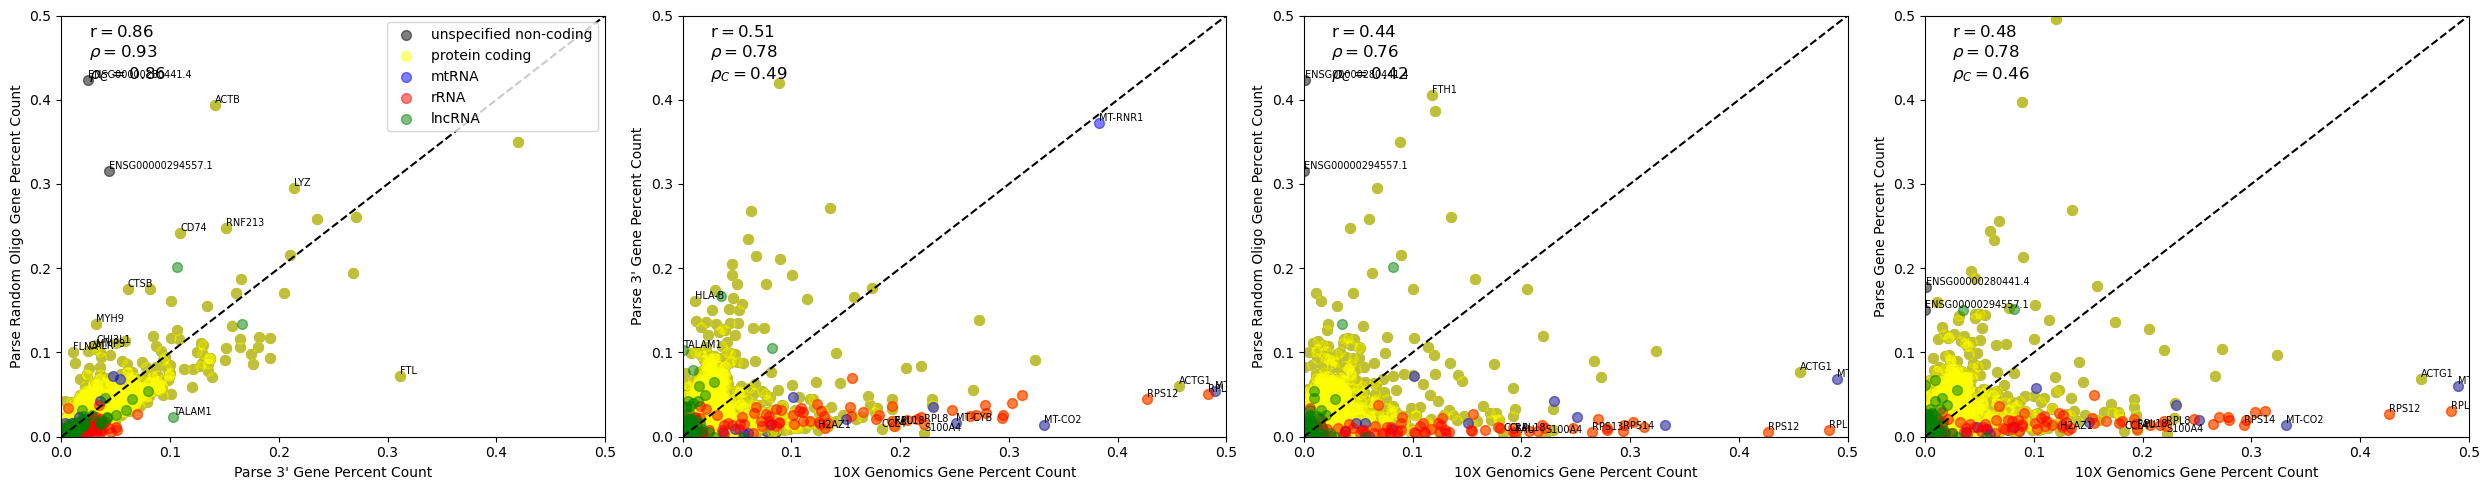

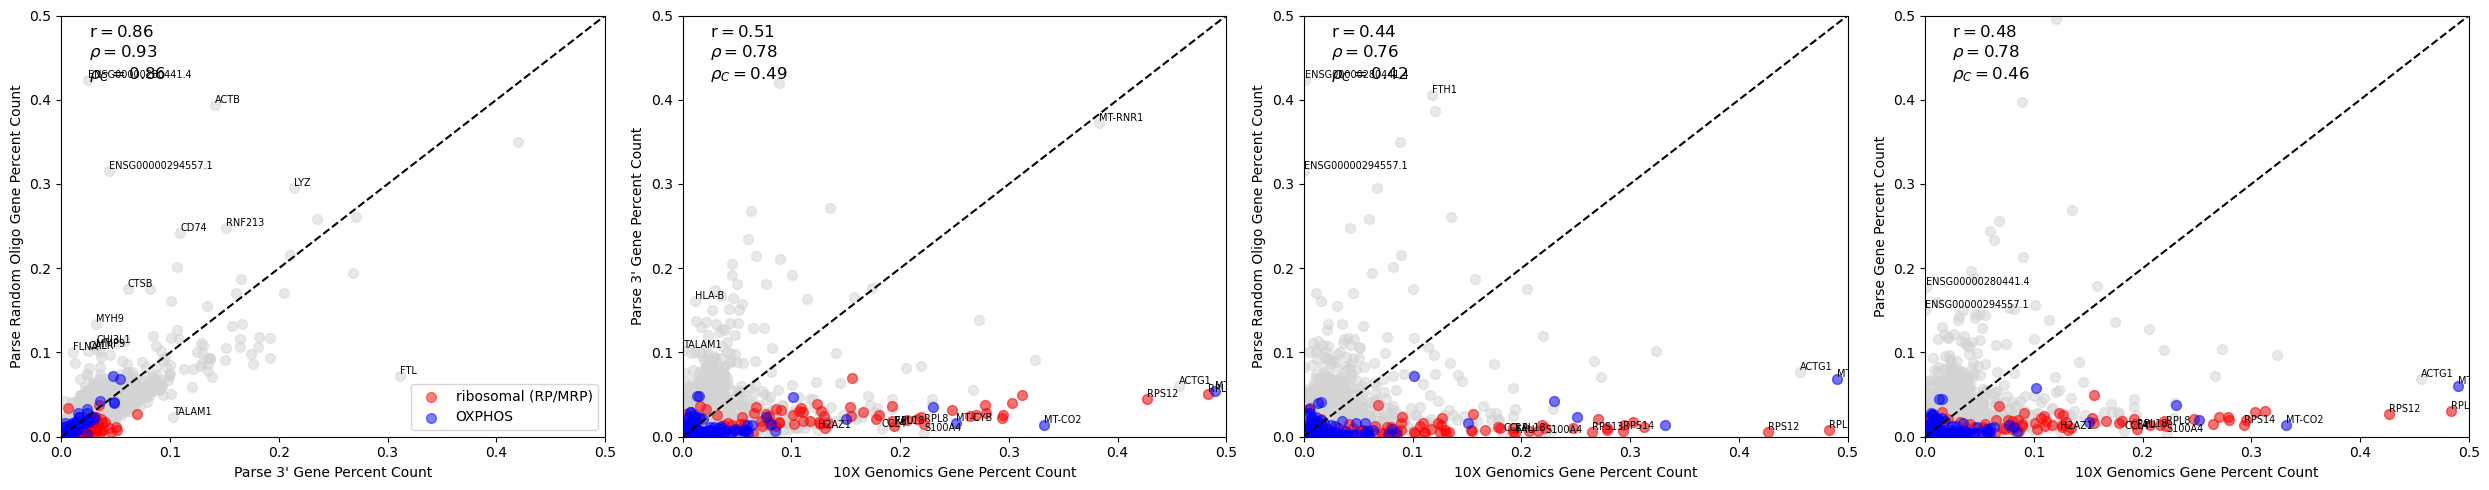

In [22]:
_, _ = plotting.compare(datasets, 0.5)

In [23]:
for name, df in zip(compare_names, compare_dfs):
    gene_info = plotting.merge_by_cooks(gene_info, name, df)

full_gene_info_path = 'gene_data/gene_comparisons.csv'
gene_info.to_csv(full_gene_info_path)

In [24]:
cell_thresh = 10

contents = plotting.generate_upset(datasets, gene_info, cell_thresh)

In [25]:
# Extract gene subsets that were interesting in the upset plot

genes_10x = contents['gene_ids'][contents['10x']& 
                                 ~contents['polyT']&
                                 ~contents['randO']&
                                 ~contents['parse']]
genes_10x = genes_10x.tolist()

genes_XO = contents['gene_ids'][contents['10x']& 
                                ~contents['polyT']&
                                contents['randO']&
                                ~contents['parse']]
genes_XO = genes_XO.tolist()

genes_XPO = contents['gene_ids'][contents['10x']& 
                                ~contents['polyT']&
                                contents['randO']&
                                contents['parse']]
genes_XPO = genes_XPO.tolist()

genes_all = contents['gene_ids'][contents['10x']& 
                                contents['polyT']&
                                contents['randO']&
                                contents['parse']]
genes_all = genes_all.tolist()

set_names = ['10X', '10X and Parse Random Oligo', '10X, Parse, and Parse Random Oligo', 'All Methods']
gene_sets = [genes_10x, genes_XO, genes_XPO, genes_all]
cols = ['is_pc', 'is_lnc', 'is_mito', 'is_ribo']
col_names = ['protein-coding count', 'lncRNA count', 'mtRNA count', 'rRNA count']
color = ['yellow', 'blue', 'red', 'green']

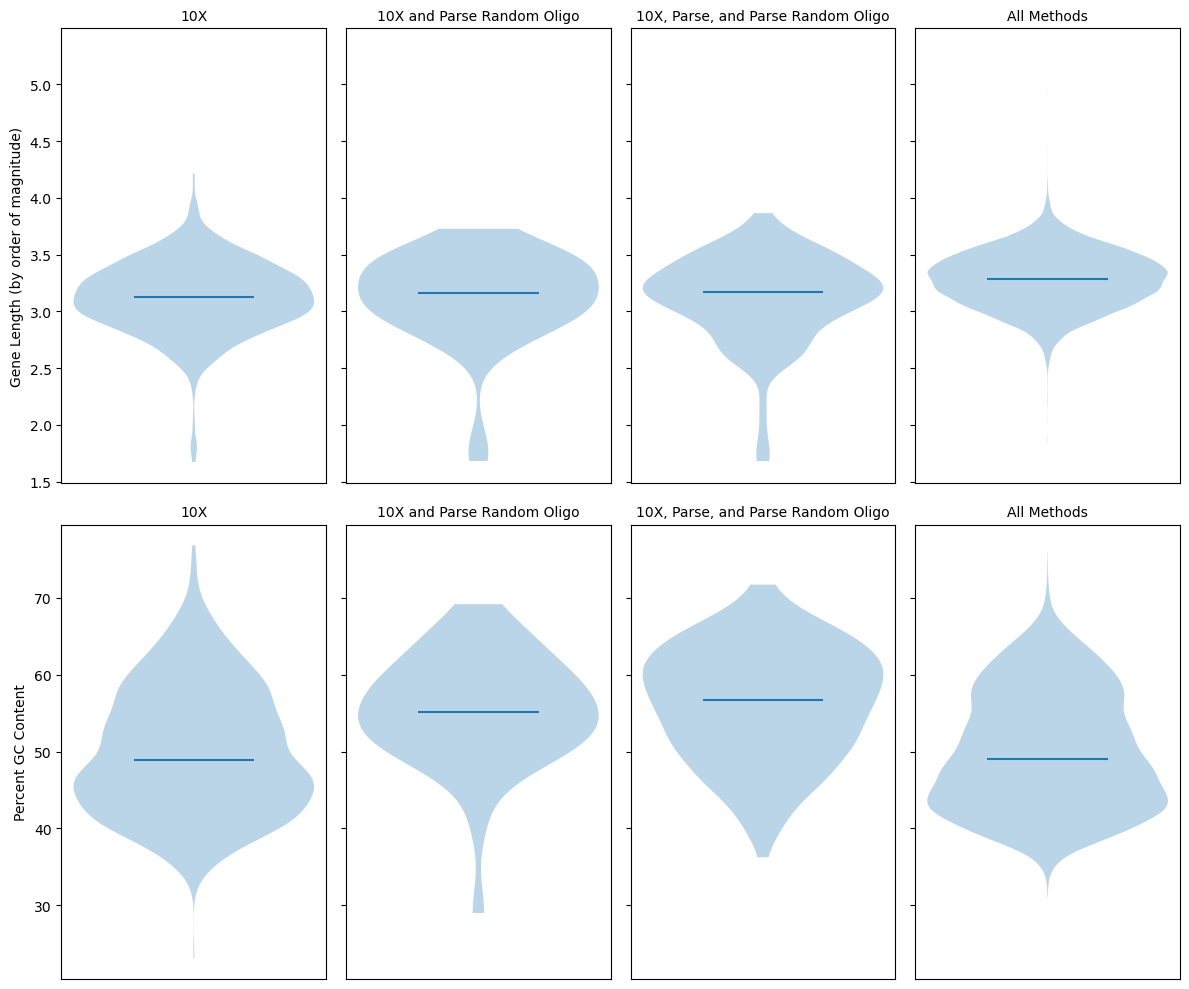

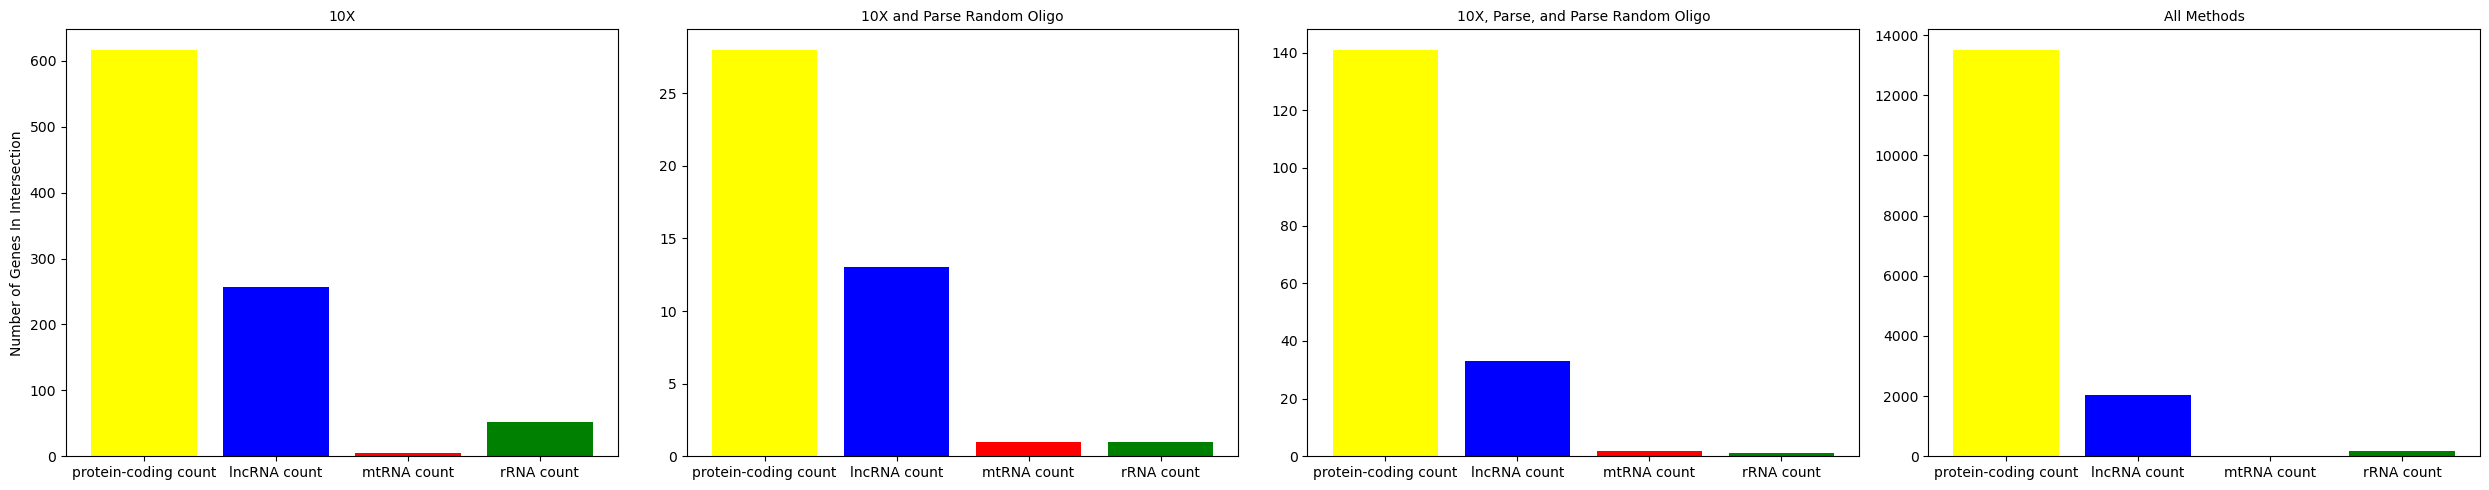

In [26]:
plotting.plot_geneset_metrics(gene_sets, set_names, gene_info)
plotting.plot_genetype_counts(gene_sets, set_names, cols, col_names, color, gene_info)

In [27]:
# Look at top 1000 genes for each method instead of all
contents = plotting.generate_upset(datasets, gene_info, cell_thresh, n_top_genes=1000)

In [28]:
genes_10x = contents['gene_ids'][contents['10x']& 
                                 ~contents['polyT']&
                                 ~contents['randO']&
                                 ~contents['parse']]
genes_10x = genes_10x.tolist()

genes_POT = contents['gene_ids'][~contents['10x']& 
                                contents['polyT']&
                                contents['randO']&
                                contents['parse']]
genes_POT = genes_POT.tolist()

genes_all = contents['gene_ids'][contents['10x']& 
                                contents['polyT']&
                                contents['randO']&
                                contents['parse']]
genes_all = genes_all.tolist()

geneset_names = ['10X', 'Parse Methods', 'All Methods']
genesets = [genes_10x, genes_POT, genes_all]
cols = ['is_pc', 'is_lnc', 'is_mito', 'is_ribo']
col_names = ['protein-coding count', 'lncRNA count', 'mtRNA count', 'rRNA count']
color = ['yellow', 'blue', 'red', 'green']

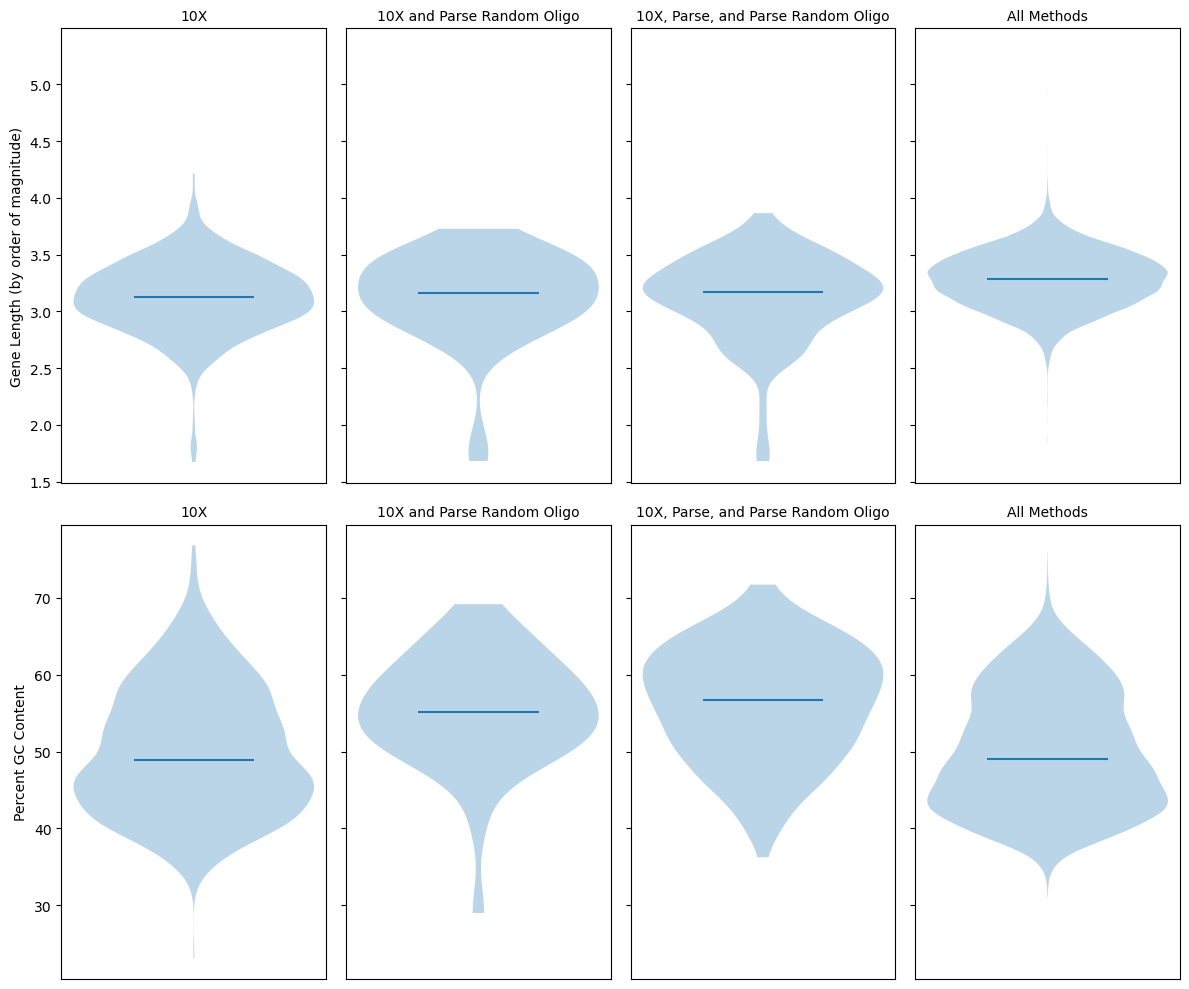

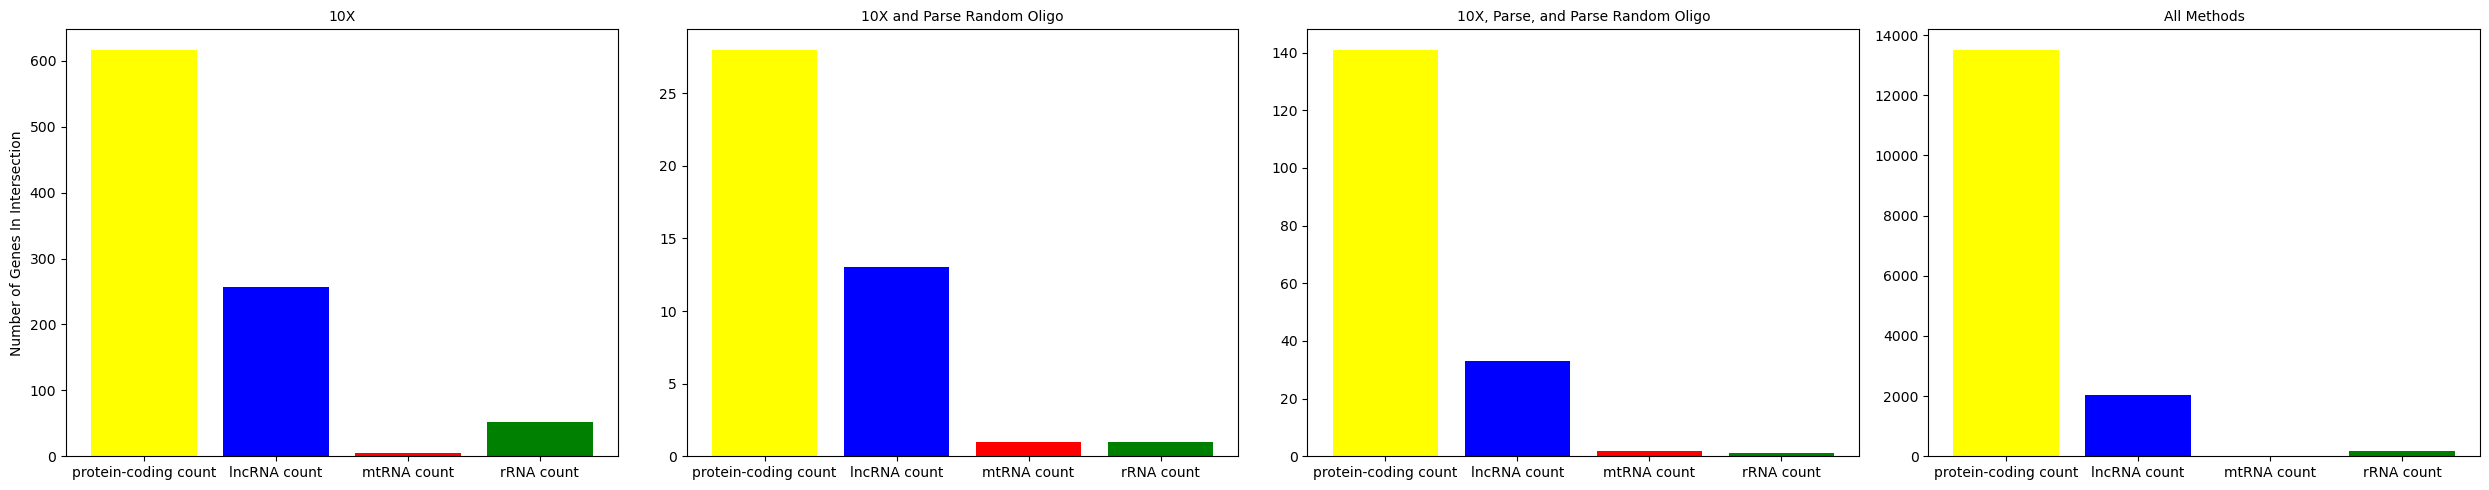

In [29]:
plotting.plot_geneset_metrics(gene_sets, set_names, gene_info)
plotting.plot_genetype_counts(gene_sets, set_names, cols, col_names, color, gene_info)